#  Setup and Foundations

**Spatial Statistics with PySpatialStats** · tutorial series · Chapter 1 of 10

| | |
|---|---|
| **Prerequisites** | Python, NumPy and pandas basics; an introductory statistics course. No GIS background assumed. |
| **You will use** | `spatialstats.core`, `spatialstats.datasets`, `spatialstats.viz`, plus GeoPandas and PyProj |
| **Data** | Bundled in the repository's `data/` folder — nothing to download |
| **Time** | about 45–60 minutes |
| **Run from** | the repository root or `examples/notebooks/` (paths are resolved automatically) |

Every later chapter — autocorrelation, regression, clustering, disease mapping, interpolation, sampling —
silently relies on four things being right: **the data are loaded correctly, the coordinate reference system
is appropriate, distances are computed in sensible units, and the first map has been looked at with a critical eye.**
This chapter builds those foundations, and shows how easily each can go wrong.

> **Split into sub-chapters** (same content, Chapter 1 style):
> [0.1 Installation and the Package Map](ch00_1_installation_and_package_map.ipynb) ·
> [0.2 Spatial Data Types and Containers](ch00_2_spatial_data_types_and_containers.ipynb) ·
> [0.3 CRS and Distances](ch00_3_crs_and_distances.ipynb) ·
> [0.4 Datasets, Maps and Workflow](ch00_4_datasets_maps_and_workflow.ipynb)


## Learning objectives

By the end of this chapter you will be able to:

1. **Install** PySpatialStats and its optional extras, **verify** the environment, and explain what happens when an optional dependency is missing.
2. **Navigate** the package: which subpackage answers which question, how they depend on each other, and what the shared *result object* offers.
3. **Distinguish** the three basic types of spatial data — geostatistical fields, lattice (areal) data and point patterns — and state the statistical model behind each.
4. **Load and organise** spatial data with GeoPandas and `SpatialData`, assign variable roles, and know what `coords_array()` really returns.
5. **Explain** what a coordinate reference system (CRS) is, why every projection distorts something, and **quantify** that distortion (Web Mercator's $\sec^2\varphi$ area inflation).
6. **Audit** a dataset's CRS — including catching a CRS tag that is *valid but wrong for the location*.
7. **Compute** Euclidean, great-circle (haversine) and pairwise distances, verify the metric axioms, and judge when an $n\times n$ distance matrix stops being affordable.
8. **Read the data catalogue**, use the synthetic teaching datasets with known truth, and avoid common key-matching and typing pitfalls.
9. **Classify and map** a variable (quantiles, equal interval, Fisher–Jenks), measure classification quality with the goodness of variance fit, and recognise misleading maps (counts vs. rates).

## Roadmap of the series

| # | Chapter | Main question | Package modules |
|---|---|---|---|
| **0** | **Setup and foundations** *(this notebook)* | Is my data loaded, projected and mapped correctly? | `core`, `datasets`, `viz` |
| 1 | Point pattern analysis | Are events clustered, random or regular? | `pointpattern` |
| 2 | Spatial autocorrelation | Are nearby values more alike than distant ones? | `weights`, `esda`, `viz` |
| 3 | Spatial regression | How do I model an outcome when errors are spatially dependent? | `regression` |
| 4 | Spatial clustering | Where are the hot spots, clusters and coherent regions? | `cluster` |
| 5 | Disease mapping & Bayesian smoothing | How do I stabilise rates in small areas? | `bayes` |
| 6 | Geographically weighted models | Do relationships vary over space? | `gwmodel` |
| 7 | Spatial interpolation | What is the value where I did not measure? | `interpolate` |
| 8 | Spatial sampling and design | Where should I sample, and how do I estimate from a sample? | `sampling` |
| 9 | Spatio-temporal analysis | How does the pattern evolve in time? | `spacetime` *(planned)* |
| 10 | Capstone | Putting it all together | all |

## 0.1 Installation and environment

### Installing

PySpatialStats keeps its **core** dependency list short (NumPy, SciPy, pandas, GeoPandas, Shapely, scikit-learn, joblib)
and puts heavy or specialised libraries behind *extras*, so that you only install what you use:

```bash
pip install pyspatialstats                  # core
pip install "pyspatialstats[viz]"           # + matplotlib, folium, mapclassify  (maps and plots)
pip install "pyspatialstats[bayes]"         # + PyMC, ArviZ                      (NUTS sampler for BYM, Chapter 5)
pip install "pyspatialstats[libpysal]"      # + libpysal                          (weights converters, cross-checks)
pip install "pyspatialstats[deep]"          # + PyTorch                           (GNNWR / GTNNWR, Chapter 6)
pip install "pyspatialstats[boosting]"      # + XGBoost, LightGBM                 (GW gradient boosting, Chapter 6)
pip install "pyspatialstats[all]"           # everything
```

or from a source checkout, in editable mode:

```bash
git clone https://github.com/zia207/PySpatialStats.git
cd PySpatialStats
pip install -e ".[all]"
```

### Setting up the notebook

The next cell imports what we need, locates the repository root (so the notebook works whether you start Jupyter
from the root or from `examples/notebooks/`), and sets a consistent plotting style.

In [1]:
import ast, importlib, importlib.util, inspect, platform, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    """Walk up from ``start`` until the folder containing ``pyproject.toml`` and ``data/`` is found."""
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:                       # package not pip-installed: fall back to the source tree
    sys.path.insert(0, str(ROOT))
    import spatialstats

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20", "grey": "#718096", "purple": "#6b46c1"}

print(f"working directory : {Path.cwd().name}/")
print(f"repository data   : {DATA.relative_to(ROOT)}/  ({len(list(DATA.iterdir()))} files)")
print(f"spatialstats      : version {spatialstats.__version__}")

working directory : notebooks/
repository data   : data/  (63 files)
spatialstats      : version 0.2.0


### Verifying the installation

A reproducible analysis records *what it ran on*. The table below lists the versions of the core stack.
Put a cell like this at the top of every analysis notebook.

In [2]:
def pkg_version(name):
    try:
        return importlib.import_module(name).__version__
    except Exception:
        return "—"

core_stack = ["numpy", "scipy", "pandas", "geopandas", "shapely", "pyproj", "sklearn", "joblib", "matplotlib"]
versions = pd.DataFrame(
    {"package": ["python", "spatialstats"] + core_stack,
     "version": [platform.python_version(), spatialstats.__version__] + [pkg_version(m) for m in core_stack]}
).set_index("package")
versions

,version
package,
python,3.11.16
spatialstats,0.2.0
numpy,2.4.6
scipy,1.17.1
pandas,3.0.6
geopandas,1.1.4
shapely,2.1.2
pyproj,3.7.2
sklearn,1.9.1


### Optional extras: what is installed here?

The extras are declared in `pyproject.toml`. Rather than trusting a hand-written table, the next cell **reads that
file** and checks, for each optional package, whether it can be imported in the environment running this notebook.

In [3]:
try:
    import tomllib
except ImportError:                       # Python < 3.11
    import tomli as tomllib

meta = tomllib.loads((ROOT / "pyproject.toml").read_text())
extras = meta["project"]["optional-dependencies"]

IMPORT_NAME = {"scikit-learn": "sklearn", "torch": "torch", "xgboost": "xgboost", "lightgbm": "lightgbm",
               "matplotlib": "matplotlib", "folium": "folium", "mapclassify": "mapclassify", "shap": "shap",
               "networkx": "networkx", "libpysal": "libpysal", "pymc": "pymc", "arviz": "arviz"}
UNLOCKS = {
    "viz": "maps, Moran scatterplot, LISA maps, natural-breaks classification (Chapters 0, 2, 4)",
    "bayes": "NUTS sampler and BYM2 for disease mapping (Chapter 5)",
    "libpysal": "weights converters; cross-checks against PySAL (Chapter 2)",
    "deep": "GNNWR / GTNNWR neural GW models (Chapter 6)",
    "boosting": "GW XGBoost / LightGBM (Chapter 6)",
    "network": "network-distance GWR (Chapter 6)",
    "shap": "SHAP importance for GW ensembles (Chapter 6)",
}

rows = []
for extra, reqs in extras.items():
    if extra in ("all", "dev"):
        continue
    for req in reqs:
        name = req.split(">")[0].split("=")[0].split("<")[0].strip()
        mod = IMPORT_NAME.get(name, name)
        rows.append({"extra": extra, "package": name,
                     "installed": importlib.util.find_spec(mod) is not None,
                     "unlocks": UNLOCKS.get(extra, "")})
extras_df = pd.DataFrame(rows)
extras_df["installed"] = extras_df["installed"].map({True: "yes", False: "no"})
extras_df

,extra,package,installed,unlocks
0,deep,torch,no,GNNWR / GTNNWR neural GW models (Chapter 6)
1,boosting,xgboost,no,GW XGBoost / LightGBM (Chapter 6)
2,boosting,lightgbm,no,GW XGBoost / LightGBM (Chapter 6)
3,viz,matplotlib,yes,"maps, Moran scatterplot, LISA maps, natural-br..."
4,viz,folium,yes,"maps, Moran scatterplot, LISA maps, natural-br..."
5,viz,mapclassify,yes,"maps, Moran scatterplot, LISA maps, natural-br..."
6,shap,shap,no,SHAP importance for GW ensembles (Chapter 6)
7,network,networkx,yes,network-distance GWR (Chapter 6)
8,libpysal,libpysal,yes,weights converters; cross-checks against PySAL...
9,bayes,pymc,yes,NUTS sampler and BYM2 for disease mapping (Cha...


### The optional-dependency pattern

A missing extra must never break `import spatialstats`, and must fail **clearly and only when the feature that needs
it is used**. The package follows one pattern everywhere: import lazily inside the function that needs the library,
and raise an `ImportError` that names the extra to install. You can see it in action with the neural-network model
(needs PyTorch) and with the PyMC backend of the Bayesian module:

In [4]:
from spatialstats.gwmodel import GNNWR
from spatialstats.bayes import pymc_available

print("PyMC available :", pymc_available())
print("PyTorch present:", importlib.util.find_spec("torch") is not None)

if importlib.util.find_spec("torch") is None:
    model = GNNWR()                                   # constructing the object is fine ...
    print("constructed    :", type(model).__name__)
    try:
        rng = np.random.default_rng(0)
        model.fit(rng.random((30, 2)), rng.random(30), rng.random((30, 2)))   # ... using it is not
    except ImportError as err:
        print("fit() raised   :", f"ImportError: {err}")
else:
    print("PyTorch is installed here, so GNNWR would train; nothing to demonstrate.")

PyMC available : True
PyTorch present: False
constructed    : GNNWR
fit() raised   : ImportError: PyTorch required: pip install torch


> **Self-test.** Once installed, run the package's smoke tests from the repository root:
>
> ```bash
> PYTHONPATH=. python tests/smoke_all_modules.py            # quick, dependency-free checks
> python -m pytest tests/test_spatial_modules.py -q         # statistical validation of the spatial modules
> ```
> Tests that compare against reference libraries (`spreg`, `pykrige`, `pointpats`, `esda`, PyMC) are skipped automatically when those libraries are absent.

## 0.2 The package map

### Subpackages at a glance

| Subpackage | Answers the question … |
|---|---|
| `core` | How do I hold spatial data, reproject it, and measure distances? |
| `weights` | Who is whose neighbour? (contiguity, k-nearest, distance band, kernel) |
| `esda` | Are values spatially autocorrelated? (Moran, Geary, Getis–Ord, join counts) |
| `viz` | How do I map results? (choropleth, Moran scatterplot, LISA map) |
| `datasets` | What data can I practise on? |
| `pointpattern` · `regression` · `cluster` · `bayes` · `interpolate` · `sampling` | The topical modules of Chapters 1, 3, 4, 5, 7, 8 |
| `gwmodel` | Do relationships vary over space? (GWR, MGWR, GW machine learning, GNNWR, …) |
| `spacetime` | *Planned* — space–time methods |

Rather than draw the architecture by hand, the next cell **derives it from the source code**: it parses every module,
finds which subpackages import which, and separates *eager* imports (executed when the package loads) from *lazy* ones
(inside a function, executed only when used). Eager edges define the layering; lazy edges are the optional couplings.

In [5]:
PKG = ROOT / "spatialstats"


def import_graph(pkg_dir: Path):
    """Return (subpackages, {(src, dst): 'eager' | 'lazy'}) from the source code of the package."""
    subs = sorted(p.name for p in pkg_dir.iterdir() if p.is_dir() and (p / "__init__.py").exists())
    edges = {}
    for sub in subs:
        for f in (pkg_dir / sub).rglob("*.py"):
            tree = ast.parse(f.read_text())
            top_level = {id(n) for n in tree.body}
            for node in ast.walk(tree):
                targets = []
                if isinstance(node, ast.ImportFrom) and node.module and node.level == 0:
                    parts = node.module.split(".")
                    if parts[0] == "spatialstats":
                        targets = [parts[1]] if len(parts) > 1 else [a.name for a in node.names]
                elif isinstance(node, ast.Import):
                    targets = [a.name.split(".")[1] for a in node.names
                               if a.name.startswith("spatialstats.") and a.name.count(".") >= 1]
                for t in targets:
                    if t in subs and t != sub:
                        kind = "eager" if id(node) in top_level else "lazy"
                        if edges.get((sub, t)) != "eager":
                            edges[(sub, t)] = kind
    return subs, edges


subs, edges = import_graph(PKG)

# layer = 1 + the deepest eager dependency (0 = depends on nothing)
eager_deps = {s: [d for (a, d), k in edges.items() if a == s and k == "eager"] for s in subs}
layer = {}
def depth(s, seen=()):
    if s in layer:
        return layer[s]
    if s in seen:                          # defensive: an eager cycle would make the layering meaningless
        return 0
    layer[s] = 0 if not eager_deps[s] else 1 + max(depth(d, seen + (s,)) for d in eager_deps[s])
    return layer[s]
for s in subs:
    depth(s)

summary = pd.DataFrame({
    "public names": [len(getattr(spatialstats, s).__all__) for s in subs],
    "status": ["ready" if len(getattr(spatialstats, s).__all__) else "planned" for s in subs],
    "layer": [layer[s] for s in subs],
    "imports (eager)": [", ".join(sorted(eager_deps[s])) or "—" for s in subs],
    "imports (lazy)": [", ".join(sorted(d for (a, d), k in edges.items() if a == s and k == "lazy")) or "—" for s in subs],
}, index=subs).sort_values(["layer", "public names"], ascending=[True, False])
summary

,public names,status,layer,imports (eager),imports (lazy)
gwmodel,26,ready,0,—,—
core,13,ready,0,—,—
datasets,6,ready,0,—,gwmodel
viz,3,ready,0,—,—
spacetime,0,planned,0,—,—
pointpattern,26,ready,1,core,—
sampling,22,ready,1,core,—
interpolate,20,ready,1,core,—
bayes,19,ready,1,core,—
cluster,19,ready,1,core,—


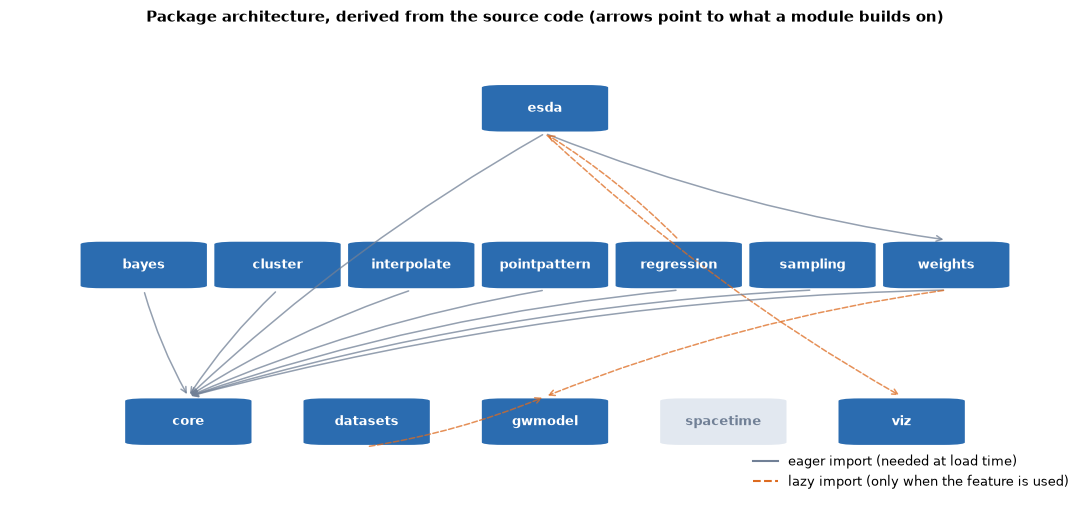

In [6]:
from matplotlib.patches import FancyBboxPatch

layers = {}
for s in subs:
    layers.setdefault(layer[s], []).append(s)
pos = {}
for L, names in layers.items():
    names = sorted(names)
    for i, s in enumerate(names):
        pos[s] = ((i + 1) / (len(names) + 1), L)

fig, ax = plt.subplots(figsize=(11, 5.2))
for (a, b), kind in edges.items():
    (x0, y0), (x1, y1) = pos[a], pos[b]
    up = y1 > y0                                             # lazy imports may point "up" the layering
    ax.annotate("", xy=(x1, y1 - 0.16 if up else y1 + 0.16), xytext=(x0, y0 + 0.16 if up else y0 - 0.16),
                arrowprops=dict(arrowstyle="->", color=C["grey"] if kind == "eager" else C["orange"],
                                lw=1.1, ls="-" if kind == "eager" else "--", alpha=0.75,
                                connectionstyle="arc3,rad=0.06"))
for s, (x, y) in pos.items():
    ready = summary.loc[s, "status"] == "ready"
    ax.add_patch(FancyBboxPatch((x - 0.055, y - 0.15), 0.11, 0.30, boxstyle="round,pad=0.005,rounding_size=0.02",
                                fc=C["blue"] if ready else "#e2e8f0", ec="white", lw=1.5))
    ax.text(x, y, s, ha="center", va="center", fontsize=9, fontweight="bold",
            color="white" if ready else C["grey"])
ax.set_xlim(0, 1); ax.set_ylim(-0.5, max(layers) + 0.5); ax.axis("off")
ax.plot([], [], color=C["grey"], label="eager import (needed at load time)")
ax.plot([], [], color=C["orange"], ls="--", label="lazy import (only when the feature is used)")
ax.legend(loc="lower right", fontsize=9)
ax.set_title("Package architecture, derived from the source code (arrows point to what a module builds on)")
plt.tight_layout(); plt.show()

Two design points follow from the graph:

* `core` sits at the bottom and depends on nothing: distance and CRS helpers are usable on their own.
* Modules that draw pictures (`esda`, `regression`, …) reach `viz` **lazily**. That is why `import spatialstats` works without matplotlib, and why plotting methods raise a helpful `ImportError` instead of breaking the import.

### A common result object

Analyses in different subpackages return objects that share one small interface, `SpatialResult`, so that once you have
learned to read one result you can read them all:

| Member | Meaning |
|---|---|
| `result.summary()` | human-readable text report |
| `result.stats` | dictionary of the scalar statistics |
| `result["name"]`, `result.get("name", default)` | direct access to one statistic |
| `result.to_frame()` | a tidy `DataFrame` (one row per observation when the result is per-area, otherwise a single row) |
| `result.plot()` | a default figure (needs the `viz` extra) |

In [7]:
from spatialstats.weights import Queen
from spatialstats.esda import Moran
from spatialstats.pointpattern import PointPattern, Window, simulate_csr, quadrat_test

ne = gpd.read_file(DATA / "diabetes_northeast.shp")          # 217 counties (loaded properly in section 0.4)
moran = Moran(ne["Dia_pct"], Queen(ne), permutations=199, seed=1)          # preview of Chapter 2
quad = quadrat_test(simulate_csr(n=200, window=Window.from_bounds(0, 0, 1, 1), seed=1), 4, 4)   # preview of Chapter 1

for res in (moran, quad):
    print(f"{type(res).__name__:14s} | name = {res.name!r:22s} | keys = {list(res.stats)[:5]} ...")
print()
print(moran.summary())
print()
print("moran['I'] =", round(moran["I"], 4), "| moran.get('p_value') =", moran.get("p_value"), "| quad.get('nope', 'default') =", quad.get("nope", "default"))
moran.to_frame().round(4)

MoranResult    | name = "Moran's I"            | keys = ['I', 'expected_I', 'var_I', 'z_score', 'p_value'] ...
QuadratResult  | name = 'Quadrat test of CSR'  | keys = ['chi2', 'df', 'p_value', 'p_clustered', 'p_regular'] ...

Moran's I
  I                    0.239826
  expected_I           -0.00462963
  var_I                0.0018983
  z_score              5.61069
  p_value              0.005
  p_norm               2.01516e-08
  p_sim                0.005
  permutations         199
  n                    217

moran['I'] = 0.2398 | moran.get('p_value') = 0.005 | quad.get('nope', 'default') = default


,I,expected_I,var_I,z_score,p_value,p_norm,p_sim,permutations,n
0,0.2398,-0.0046,0.0019,5.6107,0.005,0.0,0.005,199,217


## 0.3 What is spatial data?

### Three data types, three statistical models

Spatial statistics is organised by *what is random* and *what is fixed*. Let $D\subset\mathbb{R}^2$ be the study region and
$\mathbf{s}=(x,y)\in D$ a location.

**(a) Geostatistical (point-referenced) data.** A quantity exists everywhere and is sampled at chosen locations.
The model is a random field
$$
\{Z(\mathbf{s}) : \mathbf{s}\in D\},\qquad D \text{ continuous},
$$
observed at $\mathbf{s}_1,\dots,\mathbf{s}_n$. Its first two moments are the *mean function* and *covariance function*
$$
\mu(\mathbf{s}) = \mathbb{E}\,Z(\mathbf{s}),\qquad C(\mathbf{s},\mathbf{s}')=\operatorname{Cov}\big(Z(\mathbf{s}),Z(\mathbf{s}')\big).
$$
Under **second-order stationarity** $\mu$ is constant and $C(\mathbf{s},\mathbf{s}+\mathbf{h})=C(\mathbf{h})$ depends only on the
separation $\mathbf{h}$; the *semivariogram* $\gamma(\mathbf{h})=\tfrac12\operatorname{Var}\big[Z(\mathbf{s}+\mathbf{h})-Z(\mathbf{s})\big]=C(\mathbf{0})-C(\mathbf{h})$
is then the workhorse of interpolation (**Chapter 7**). *Example: PM2.5 at monitoring stations.*

**(b) Lattice (areal) data.** The locations are a fixed, discrete set of regions $A_1,\dots,A_n$ that tile $D$
(counties, tracts). The data are a vector $\mathbf{z}=(Z_1,\dots,Z_n)^\top$, and what matters is *which regions are neighbours*,
encoded in an $n\times n$ **spatial weights matrix** $\mathbf{W}=(w_{ij})$ (**Chapters 2–6**). *Example: diabetes prevalence by county.*

**(c) Point patterns.** The *locations themselves* are random. A pattern is a random set of points $\mathbf{X}\subset D$, described by
its counting measure $N(B)=\#\{\mathbf{X}\cap B\}$ and its **intensity**
$$
\lambda(\mathbf{s})=\lim_{|d\mathbf{s}|\to 0}\frac{\mathbb{E}\,N(d\mathbf{s})}{|d\mathbf{s}|}.
$$
The reference model is *complete spatial randomness* (CSR): a homogeneous Poisson process, $N(B)\sim\text{Poisson}(\lambda|B|)$ (**Chapter 1**).
*Example: crime incidents.*

The three cover the same map differently: the same crime data could be a point pattern (locations), a lattice (counts per
neighbourhood) or a field (smoothed risk surface). Choosing the representation is the first modelling decision.

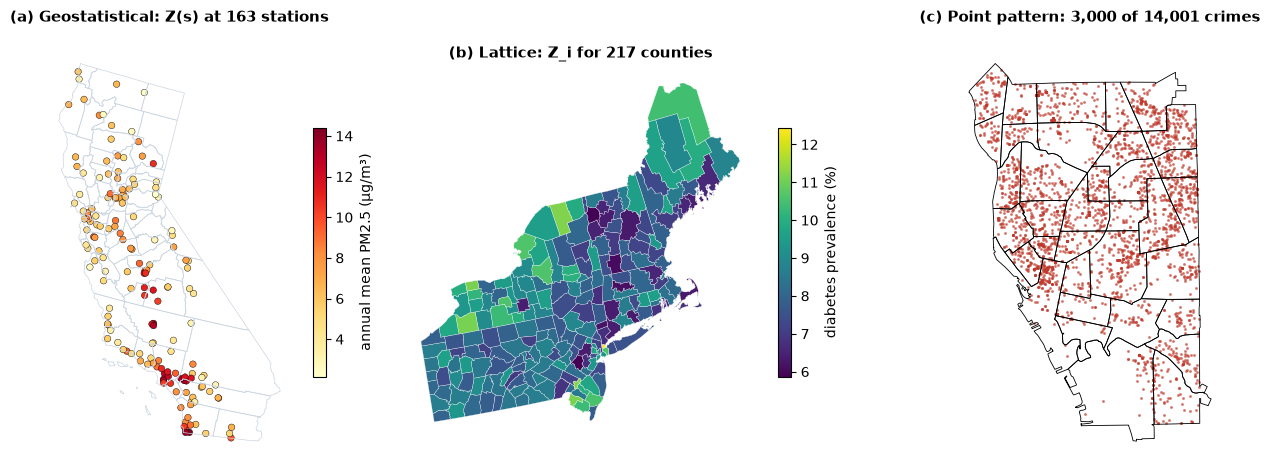

In [8]:
uc = gpd.read_file(DATA / "US_COUNTY.shp")
ca_counties = uc[uc["STATE"] == "California"]

pm = pd.read_csv(DATA / "CA_pm25_2025.csv")
sites = (pm.groupby("Site ID").agg(lat=("Lat", "mean"), lon=("Long", "mean"), pm25=("Daily_PM2.5_ug_m3", "mean"))
           .reset_index())
sites = gpd.GeoDataFrame(sites, geometry=gpd.points_from_xy(sites["lon"], sites["lat"]), crs=4326).to_crs(uc.crs)

city = gpd.read_file(DATA / "buffalo_city.shp")
crimes = gpd.read_file(DATA / "Crime_location_2018.shp")
crimes_sub = crimes.iloc[np.random.default_rng(0).choice(len(crimes), 3000, replace=False)]
# For drawing we use UTM 17N, the correct zone for Buffalo (section 0.5 explains why the files' own CRS is not used)
city_map = city.to_crs(4326).to_crs(26917)
crimes_map = crimes_sub.to_crs(4326).to_crs(26917)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
ca_counties.boundary.plot(ax=axes[0], color="#cbd5e0", lw=0.5)
sites.plot(ax=axes[0], column="pm25", cmap="YlOrRd", markersize=22, edgecolor="k", linewidth=0.3, legend=True,
           legend_kwds={"shrink": 0.6, "label": "annual mean PM2.5 (µg/m³)"})
axes[0].set_title(f"(a) Geostatistical: Z(s) at {len(sites)} stations")

ne.plot(ax=axes[1], column="Dia_pct", cmap="viridis", edgecolor="white", linewidth=0.2, legend=True,
        legend_kwds={"shrink": 0.6, "label": "diabetes prevalence (%)"})
axes[1].set_title(f"(b) Lattice: Z_i for {len(ne)} counties")

city_map.boundary.plot(ax=axes[2], color="k", lw=0.6)
crimes_map.plot(ax=axes[2], markersize=1.5, color=C["red"], alpha=0.5)
axes[2].set_title("(c) Point pattern: 3,000 of 14,001 crimes")
for a in axes:
    a.set_axis_off()
plt.tight_layout(); plt.show()

### Every spatial dataset has three parts

$$
\text{spatial data} \;=\; \underbrace{\text{geometry}}_{\text{points, lines, polygons}} \;+\; \underbrace{\text{attributes}}_{\text{a table: one row per feature}} \;+\; \underbrace{\text{CRS}}_{\text{what the numbers in the geometry mean}}.
$$

Beginners tend to look after the first two and forget the third; most of this chapter is about why that is a mistake.

### Support and the modifiable areal unit problem

A county value is not a measurement at a point; it is an *aggregate* over a region, typically
$$
Z_i=\frac{1}{|A_i|}\int_{A_i} Z(\mathbf{s})\,d\mathbf{s}\quad(\text{a mean})\qquad\text{or}\qquad Y_i=\int_{A_i}\lambda(\mathbf{s})\,d\mathbf{s}\quad(\text{an expected count}).
$$
Change the boundaries, or the level of aggregation, and the numbers — and any correlation computed from them — change.
This is the **modifiable areal unit problem (MAUP)** (Openshaw, 1984). Keep it in mind whenever a result depends on a particular partition of space.

## 0.4 Spatial data containers (`spatialstats.core`)

### Loading data with GeoPandas

PySpatialStats does not invent a new data format. Vector data are read with GeoPandas into a `GeoDataFrame`:
an ordinary pandas table with one special column, `geometry`. We use **diabetes prevalence for 217 counties in the northeastern
United States** as the running example of a lattice.

In [9]:
ne = gpd.read_file(DATA / "diabetes_northeast.shp")
print(f"{type(ne).__name__}: {ne.shape[0]} rows x {ne.shape[1]} columns | CRS: {ne.crs.name} (EPSG:{ne.crs.to_epsg()})")
print("geometry types:", ne.geom_type.value_counts().to_dict())
fields = pd.DataFrame({
    "dtype": ne.drop(columns="geometry").dtypes.astype(str),
    "example": ne.drop(columns="geometry").iloc[0].astype(str),
})
fields["meaning"] = pd.Series({
    "FIPS": "5-digit county code (numeric)", "STATE": "state name", "COUNTY": "county name",
    "x": "county centroid, easting (m)", "y": "county centroid, northing (m)", "POP_Total": "population",
    "Dia_count": "number of diabetes cases", "Dia_pct": "diabetes prevalence (%)", "Obesity": "obesity prevalence (%)",
    "Acc_Exer": "access to exercise opportunities (%)", "PhysInact": "physical inactivity (%)",
    "PCP_rate": "primary-care physicians per 100k", "FoodEnvIdx": "food environment index (0-10)",
    "SVI": "social vulnerability index", "UrbRural": "'Urban' / 'Rural'"})
fields

GeoDataFrame: 217 rows x 16 columns | CRS: NAD83 / Conus Albers (EPSG:5070)
geometry types: {'Polygon': 206, 'MultiPolygon': 11}


,dtype,example,meaning
FIPS,int64,9001,5-digit county code (numeric)
STATE,str,Connecticut,state name
COUNTY,str,Fairfield County,county name
x,float64,1861863.825,"county centroid, easting (m)"
y,float64,2251708.214,"county centroid, northing (m)"
POP_Total,float64,944735.8,population
Dia_count,int64,52448,number of diabetes cases
Dia_pct,float64,6.42,diabetes prevalence (%)
Obesity,float64,21.48,obesity prevalence (%)
Acc_Exer,float64,96.6,access to exercise opportunities (%)


### `SpatialData`: a table with roles

Statistical code needs to know *which column is the response, which are covariates, and where the coordinates are*.
`SpatialData` wraps a `GeoDataFrame` and records these **roles**, so downstream code does not have to guess and you
do not have to keep slicing columns by hand. It is deliberately thin: `sd.gdf` is always your GeoDataFrame.

In [10]:
from spatialstats.core import SpatialData

sd = SpatialData(ne, y="Dia_pct", X=["Obesity", "PhysInact", "SVI"])
print(sd)                                        # note: geometry type is reported as 'Mixed' (why?)
print()
print("y_array()      ->", sd.y_array().shape, "  first values:", sd.y_array()[:4])
print("X_array()      ->", sd.X_array().shape)
print("coords_array() ->", sd.coords_array().shape, " first row:", sd.coords_array()[0].round(1))
print("crs            ->", sd.crs.name)

SpatialData(n=217, geom=Mixed, crs=EPSG:5070, roles={'y': ['Dia_pct'], 'X': ['Obesity', 'PhysInact', 'SVI']})

y_array()      -> (217,)   first values: [6.42 8.58 6.38 6.32]
X_array()      -> (217, 3)
coords_array() -> (217, 2)  first row: [1866793.1 2254200.7]
crs            -> NAD83 / Conus Albers


Two observations, both worth internalising:

* `geometry_type` says **`Mixed`** because the layer holds both `Polygon` and `MultiPolygon` features (counties with islands or detached parts). It is not an error — but code that assumes one geometry type will break on such data.
* `coords_array()` needs one $(x,y)$ location per county. For polygons it returns a **representative point** — a point guaranteed to lie *inside* the polygon — **not the centroid**. The docstring of the method speaks of centroids; the function actually called is `coords_from_geometry`, which uses `representative_point()`. The difference matters, as the next cell shows.

### Centroid versus representative point

The centroid is the polygon's centre of mass, $\bar{\mathbf s}=\frac{1}{|A|}\int_A \mathbf{s}\,d\mathbf{s}$. For a concave shape (a crescent, a coastline, a county wrapped around a bay) it can lie *outside* the polygon. A representative point is always inside, but is not the centre of mass.
The shapefile carries true centroids in the `x`, `y` columns, so we can measure the gap.

**Distance between centroid and representative point** over 217 counties: median 2.7 km, mean 3.6 km, maximum 32.8 km. **0 centroids fall outside their own county.**

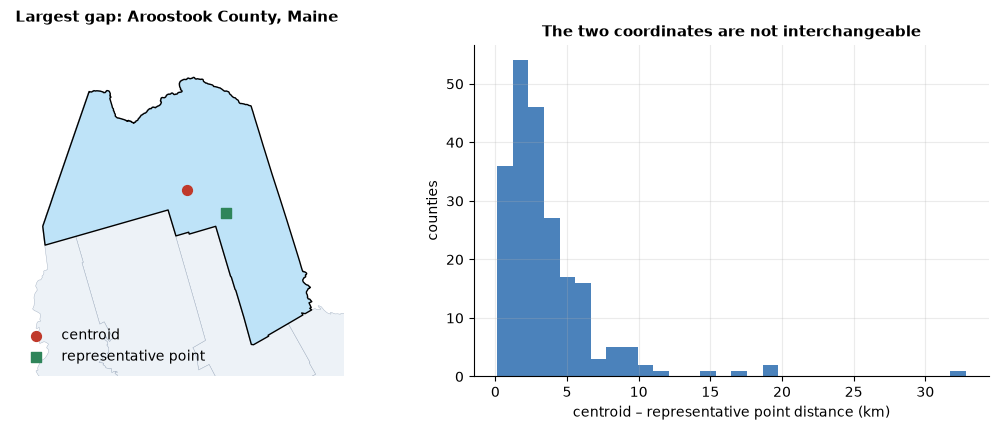

In [11]:
cent = ne[["x", "y"]].to_numpy()                     # true centroids stored in the file
rep = sd.coords_array()                              # representative points used by SpatialData
gap_km = np.linalg.norm(rep - cent, axis=1) / 1000
outside = ~gpd.GeoSeries(gpd.points_from_xy(cent[:, 0], cent[:, 1]), crs=ne.crs).within(ne.geometry).to_numpy()

display(Markdown(
    f"**Distance between centroid and representative point** over {len(ne)} counties: "
    f"median {np.median(gap_km):.1f} km, mean {gap_km.mean():.1f} km, maximum {gap_km.max():.1f} km. "
    f"**{outside.sum()} centroids fall outside their own county.**"))

worst = int(gap_km.argmax())
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
ne.plot(ax=ax[0], color="#edf2f7", edgecolor="#a0aec0", linewidth=0.3)
ne.iloc[[worst]].plot(ax=ax[0], color="#bee3f8", edgecolor="k")
x0_, y0_, x1_, y1_ = ne.iloc[worst].geometry.bounds                   # zoom to the county, keep its neighbours as context
pad = 0.12 * max(x1_ - x0_, y1_ - y0_)
ax[0].set_xlim(x0_ - pad, x1_ + pad); ax[0].set_ylim(y0_ - pad, y1_ + pad)
ax[0].scatter(*cent[worst], c=C["red"], s=50, zorder=5, label="centroid")
ax[0].scatter(*rep[worst], c=C["green"], s=50, marker="s", zorder=5, label="representative point")
ax[0].set_title(f"Largest gap: {ne.COUNTY.iloc[worst]}, {ne.STATE.iloc[worst]}")
ax[0].legend(loc="lower left"); ax[0].set_axis_off()
ax[1].hist(gap_km, bins=30, color=C["blue"], alpha=0.85)
ax[1].set_xlabel("centroid – representative point distance (km)"); ax[1].set_ylabel("counties")
ax[1].set_title("The two coordinates are not interchangeable")
plt.tight_layout(); plt.show()

**Practical rule:** if a method is sensitive to the *precise* location (distance-band weights, kernels, kriging), decide which point you mean, and tell `SpatialData` explicitly with the `coords` role.

In [12]:
# Option 1: tell SpatialData to use the centroid *columns* stored in the file (a separate object, so `sd` stays untouched)
sd_cols = SpatialData(ne, y="Dia_pct").set_roles(coords=["x", "y"])
print("coords role = ['x', 'y'] -> equals the stored centroids:", np.allclose(sd_cols.coords_array(), cent))

# Option 2: build SpatialData from a plain table with coordinate columns; the points get their geometry from x, y
table = ne.drop(columns="geometry")
sd_pts = SpatialData.from_frame(table, x_col="x", y_col="y", crs=ne.crs, y="Dia_pct")
print(sd_pts)
print("from_frame also sets the coords role:", sd_pts.roles["coords"])

coords role = ['x', 'y'] -> equals the stored centroids: True
SpatialData(n=217, geom=Point, crs=EPSG:5070, roles={'y': ['Dia_pct'], 'coords': ['x', 'y']})
from_frame also sets the coords role: ['x', 'y']


### Reprojection helpers

`SpatialData.to_crs()` returns a *new* object (the original is untouched) with roles preserved, and `ensure_projected()`
converts geographic (latitude/longitude) data to a projected CRS but leaves already-projected data alone. We meet the reasons
for both in section 0.5.

> **A trap worth knowing.** Reprojection transforms the **geometry**. If the `coords` role points at *columns* — because you set it, or because
> `from_frame()` did — those columns are copied unchanged, and `coords_array()` keeps returning the **old, un-reprojected numbers**. The last three lines of the next cell show it.
> When you reproject a `SpatialData`, either rely on the geometry (leave the `coords` role unset) or rebuild the coordinate columns.

In [13]:
sd_ll = sd.to_crs(4326)                                # degrees
print("to_crs(4326)        :", sd_ll.crs.name, "| first coordinates:", sd_ll.coords_array()[0].round(4), "(lon, lat)")
print("roles preserved     :", {k: v for k, v in sd_ll.roles.items() if v})
print("ensure_projected() on already-projected data ->", sd.ensure_projected().crs.name, "(unchanged)")
print("ensure_projected() on lon/lat data          ->", sd_ll.ensure_projected().crs.name, "(default target!)")

# --- The trap: a coords role that names COLUMNS is not reprojected ------------------------------
for label, obj in [("coords role = ['x','y'] columns", sd_cols), ("built with from_frame()", sd_pts)]:
    moved = obj.to_crs(4326)
    print(f"\n{label}: geometry is now {moved.crs.name}, but coords_array()[0] = {moved.coords_array()[0].round(1)}")
fixed = sd_cols.to_crs(4326)
fixed.roles["coords"] = None                             # drop the stale role -> coordinates come from the geometry again
print("\nafter dropping the stale role         : coords_array()[0] =", fixed.coords_array()[0].round(4), "(lon, lat)")

to_crs(4326)        : WGS 84 | first coordinates: [-73.3234  41.3228] (lon, lat)
roles preserved     : {'y': ['Dia_pct'], 'X': ['Obesity', 'PhysInact', 'SVI']}
ensure_projected() on already-projected data -> NAD83 / Conus Albers (unchanged)
ensure_projected() on lon/lat data          -> WGS 84 / Pseudo-Mercator (default target!)

coords role = ['x','y'] columns: geometry is now WGS 84, but coords_array()[0] = [1861863.8 2251708.2]

built with from_frame(): geometry is now WGS 84, but coords_array()[0] = [1861863.8 2251708.2]

after dropping the stale role         : coords_array()[0] = [-73.3234  41.3228] (lon, lat)


## 0.5 Coordinate reference systems

### Theory: from an ellipsoid to a flat map

The Earth is not flat, not a sphere, but close to an **oblate ellipsoid** of revolution. WGS 84 has semi-major axis
$a=6\,378\,137$ m and flattening $f=1/298.257223563$, giving eccentricity $e^2=f(2-f)\approx0.00669$.
Positions on it are **geodetic coordinates**: latitude $\varphi$ (north–south), longitude $\lambda$ (east–west), in degrees.
A **coordinate reference system** (CRS) specifies (i) a *datum* (which ellipsoid, anchored where) and, for projected systems,
(ii) a **map projection**
$$
(x,y)=P(\varphi,\lambda),
$$
plus units. A projected CRS lets us use plane geometry — Euclidean distance, area by the shoelace formula — but a curved surface
cannot be flattened without distortion (Gauss's *Theorema Egregium*). Locally the projection turns an infinitesimal circle
into an ellipse; its axes are the **scale factors** $h$ (along meridians) and $k$ (along parallels). Then

$$
\text{distance scale}\approx k,\qquad \text{area scale}\approx h\,k .
$$

Projections are classified by what they preserve: **conformal** ($h=k$: angles and local shapes), **equal-area** ($hk=1$: areas), **equidistant** (distances from a point or line). No projection preserves all of them.

**Web Mercator** (EPSG:3857, the CRS of web maps) is conformal. On a sphere of radius $R$:
$$
x=R\lambda,\qquad y=R\ln\tan\!\Big(\frac{\pi}{4}+\frac{\varphi}{2}\Big),\qquad h=k=\sec\varphi,
$$
so distances are inflated by $\sec\varphi$ and **areas by $\sec^2\varphi$** — a factor of $1.81$ at $42^\circ$N. **Albers equal-area conic** (e.g. EPSG:5070 for the contiguous US) has $hk=1$ everywhere by construction.

**Geographic** CRSs (EPSG:4326) are *not* projections: coordinates are degrees, so "Euclidean distance" is in degrees, and one degree of longitude
is $\tfrac{\pi}{180}R\cos\varphi$ long — 111 km at the equator, 0 at the pole.

In [14]:
from pyproj import Geod
from spatialstats.core import validate_crs, is_geographic, is_projected, to_crs, ensure_projected

inventory = []
for epsg in [4326, 3857, 5070, 3310, 26917, 3718]:
    crs = validate_crs(f"EPSG:{epsg}")
    inventory.append({
        "EPSG": epsg, "name": crs.name,
        "kind": "geographic" if is_geographic(crs) else "projected" if is_projected(crs) else "other",
        "unit": crs.axis_info[0].unit_name,
        "designed for": crs.area_of_use.name[:58] + ("…" if len(crs.area_of_use.name) > 58 else ""),
    })
pd.DataFrame(inventory).set_index("EPSG")

,name,kind,unit,designed for
EPSG,,,,
4326,WGS 84,geographic,degree,World.
3857,WGS 84 / Pseudo-Mercator,projected,metre,World between 85.06°S and 85.06°N.
5070,NAD83 / Conus Albers,projected,metre,United States (USA) - CONUS onshore - Alabama;...
3310,NAD83 / California Albers,projected,metre,United States (USA) - California.
26917,NAD83 / UTM zone 17N,projected,metre,North America - between 84°W and 78°W - onshor...
3718,NAD83(NSRS2007) / UTM zone 11N,projected,metre,United States (USA) - between 120°W and 114°W ...


### How much does the choice of CRS matter? A measurement

Take the 217 northeastern counties. We can compute each county's **true (geodesic) area on the ellipsoid** with PyProj,
and compare it with the *planar* area obtained after projecting to several CRSs. If Mercator theory is right, the ratio
$A_{3857}/A_{\text{geodesic}}$ should equal $\sec^2\varphi$ county by county.

,total area (km²),ratio to geodesic,worst county (ratio)
Web Mercator (3857),812869.2800,1.8623,2.1229
"CONUS Albers, equal-area (5070)",436475.7125,1.0000,0.9999
UTM 18N (32618),436972.3416,1.0011,1.0075
Global equal-area cylindrical (6933),436475.4710,1.0000,0.9990
geodesic (truth),436475.9104,1.0000,1.0000


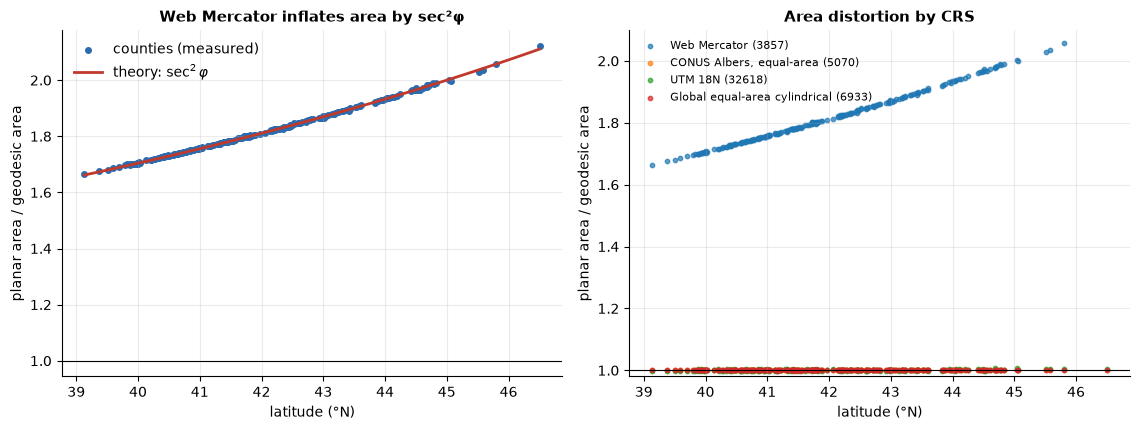

**Take-away.** Correlation between the measured Mercator area ratio and $\sec^2\varphi$ is **0.9997**; summed over the region Web Mercator reports **1.86×** the true area. An equal-area CRS is within 0.0000% of the truth in total, and within 0.011% in the worst county.

In [15]:
geod = Geod(ellps="WGS84")
ne_ll = ne.to_crs(4326)
geodesic_km2 = np.array([abs(geod.geometry_area_perimeter(g)[0]) for g in ne_ll.geometry]) / 1e6

candidates = {"Web Mercator (3857)": 3857, "CONUS Albers, equal-area (5070)": 5070,
              "UTM 18N (32618)": 32618, "Global equal-area cylindrical (6933)": 6933}
planar_km2 = {name: ne.to_crs(code).area.to_numpy() / 1e6 for name, code in candidates.items()}

ratio_table = pd.DataFrame({
    "total area (km²)": {name: a.sum() for name, a in planar_km2.items()},
    "ratio to geodesic": {name: a.sum() / geodesic_km2.sum() for name, a in planar_km2.items()},
    "worst county (ratio)": {name: (a / geodesic_km2)[np.argmax(np.abs(a / geodesic_km2 - 1))]
                             for name, a in planar_km2.items()},
})
ratio_table.loc["geodesic (truth)"] = [geodesic_km2.sum(), 1.0, 1.0]
display(ratio_table.round(4))

lat = ne_ll.geometry.representative_point().y.to_numpy()
sec2 = 1 / np.cos(np.radians(lat)) ** 2
merc_ratio = planar_km2["Web Mercator (3857)"] / geodesic_km2

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax[0].scatter(lat, merc_ratio, s=16, color=C["blue"], label="counties (measured)")
grid_lat = np.linspace(lat.min(), lat.max(), 100)
ax[0].plot(grid_lat, 1 / np.cos(np.radians(grid_lat)) ** 2, color=C["red"], lw=2, label=r"theory: $\sec^2\varphi$")
ax[0].axhline(1, color="k", lw=0.8)
ax[0].set(xlabel="latitude (°N)", ylabel="planar area / geodesic area", title="Web Mercator inflates area by sec²φ")
ax[0].legend()
for name, a in planar_km2.items():
    ax[1].scatter(lat, a / geodesic_km2, s=10, alpha=0.7, label=name)
ax[1].axhline(1, color="k", lw=0.8)
ax[1].set(xlabel="latitude (°N)", ylabel="planar area / geodesic area", title="Area distortion by CRS", ylim=(0.98, 2.1))
ax[1].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

r = np.corrcoef(merc_ratio, sec2)[0, 1]
display(Markdown(
    f"**Take-away.** Correlation between the measured Mercator area ratio and $\\sec^2\\varphi$ is **{r:.4f}**; "
    f"summed over the region Web Mercator reports **{ratio_table.loc['Web Mercator (3857)', 'ratio to geodesic']:.2f}×** the true area. "
    f"An equal-area CRS is within {abs(ratio_table.loc['CONUS Albers, equal-area (5070)', 'ratio to geodesic'] - 1) * 100:.4f}% of the truth in total, "
    f"and within {abs(ratio_table.loc['CONUS Albers, equal-area (5070)', 'worst county (ratio)'] - 1) * 100:.3f}% in the worst county."))

### Distances suffer too

Areas are distorted by $hk$, distances by $k$. Let us measure the distance between two cities about 220 km apart, five ways.

In [16]:
from pyproj import Transformer

albany, boston = (-73.7562, 42.6526), (-71.0589, 42.3601)              # (lon, lat)
d_true = geod.inv(*albany, *boston)[2] / 1000                          # geodesic on the ellipsoid, km

def euclid_in(epsg):
    tr = Transformer.from_crs(4326, epsg, always_xy=True)
    (x1, y1), (x2, y2) = tr.transform(*albany), tr.transform(*boston)
    return np.hypot(x2 - x1, y2 - y1) / 1000

rows = {
    "geodesic on WGS84 ellipsoid (truth)": d_true,
    "Euclidean on raw degrees × 111.32 km": np.hypot((boston[0] - albany[0]), (boston[1] - albany[1])) * 111.32,
    "Euclidean in Web Mercator (3857)": euclid_in(3857),
    "Euclidean in CONUS Albers (5070)": euclid_in(5070),
    "Euclidean in UTM 18N (32618)": euclid_in(32618),
}
dist_table = pd.DataFrame({"distance (km)": rows})
dist_table["error vs truth (%)"] = 100 * (dist_table["distance (km)"] / d_true - 1)
dist_table.round(2)

,distance (km),error vs truth (%)
geodesic on WGS84 ellipsoid (truth),224.05,0.00
Euclidean on raw degrees × 111.32 km,302.02,34.80
Euclidean in Web Mercator (3857),303.49,35.46
Euclidean in CONUS Albers (5070),222.70,-0.61
Euclidean in UTM 18N (32618),224.10,0.02


The raw-degree shortcut is off by about a third because a degree of longitude at $42^\circ$N is only $111.32\cos 42^\circ\approx 82.7$ km.
Web Mercator inflates by $\sec 42^\circ\approx 1.35$. A projection *suited to the region* — the local UTM zone here, or the equal-area Albers used for the whole US — is within a fraction of a percent.

**Rule of thumb.** Any method that uses distance — distance-band or kernel weights, kriging, K-functions, GWR bandwidths, DBSCAN — needs coordinates in a **projected CRS with metric units**, chosen for the study area: a regional equal-area or conformal projection (CONUS Albers 5070, California Albers 3310) or the local UTM zone. `ensure_projected()` defaults to Web Mercator (3857) only because it works everywhere; **pass `target_crs=` explicitly** for real work.

In [17]:
# ensure_projected: three behaviours worth knowing
geo = ne.to_crs(4326)
print("lon/lat -> default target        :", ensure_projected(geo).crs.to_epsg())
print("lon/lat -> explicit target_crs   :", ensure_projected(geo, target_crs=5070).crs.to_epsg())
print("already projected -> returned as-is :", ensure_projected(ne).crs.to_epsg())

nocrs = gpd.GeoDataFrame(ne.drop(columns="geometry"), geometry=list(ne.geometry))   # same data, CRS forgotten
print("CRS of the copy:", nocrs.crs)
try:
    ensure_projected(nocrs)
except ValueError as err:
    print("no CRS -> ValueError                :", err)

lon/lat -> default target        : 3857
lon/lat -> explicit target_crs   : 5070
already projected -> returned as-is : 5070
CRS of the copy: None
no CRS -> ValueError                : GeoDataFrame has no CRS. Set gdf.crs or pass a projected dataset.


### Case study: a CRS tag that is valid but wrong

Software can tell you whether a CRS *exists*; only you can check that it is *right for the place*. The Buffalo, NY crime and neighbourhood
files declare a projected CRS. Let us audit it. The audit has four steps: read the declared CRS and its **area of use**; convert the data
back to longitude/latitude; test whether the location falls inside the area of use; and, if not, measure how badly distances and areas are distorted.

In [18]:
city = gpd.read_file(DATA / "buffalo_city.shp")
crimes = gpd.read_file(DATA / "Crime_location_2018.shp")
crime_tbl = pd.read_csv(DATA / "crime_data_2018.csv")            # the same events with lon/lat columns

declared = city.crs
west, south, east, north = declared.area_of_use.bounds
ll = city.to_crs(4326)
union = ll.geometry.union_all() if hasattr(ll.geometry, "union_all") else ll.geometry.unary_union
lon0, lat0 = union.centroid.x, union.centroid.y

print(f"declared CRS      : {declared.name}")
deg = lambda v, pos, neg: f"{abs(v):.1f}°{pos if v >= 0 else neg}"
print(f"designed for      : longitudes {deg(west, 'E', 'W')} to {deg(east, 'E', 'W')}, latitudes {deg(south, 'N', 'S')} to {deg(north, 'N', 'S')}")
print(f"data are located  : longitude {deg(lon0, 'E', 'W')}, latitude {deg(lat0, 'N', 'S')}  (Buffalo, New York)")
print(f"inside the CRS's area of use?  {west <= lon0 <= east and south <= lat0 <= north}")

declared CRS      : NAD83(NSRS2007) / UTM zone 11N
designed for      : longitudes 120.0°W to 114.0°W, latitudes 30.9°N to 49.0°N
data are located  : longitude 78.8°W, latitude 42.9°N  (Buffalo, New York)
inside the CRS's area of use?  False


Buffalo is at $78.9^\circ$W; **UTM zone 11N** is centred on $117^\circ$W and designed for $114^\circ$–$120^\circ$W. The data are $38^\circ$ from the central meridian.
Transverse Mercator can be computed that far out, so no error is raised — but two things grow away from the central meridian $\lambda_0$: the scale factor and the **grid convergence** $\gamma$
(the angle between grid north and true north). On a sphere,
$$
k=\frac{k_0}{\sqrt{1-B^{2}}},\quad B=\cos\varphi\,\sin(\lambda-\lambda_0),\quad k_0=0.9996;\qquad
\gamma=\arctan\!\big(\tan(\lambda-\lambda_0)\,\sin\varphi\big).
$$
Distances are inflated by $k$, areas by $k^2$, and the whole map is rotated by $\gamma$. We can check both predictions against measurements: geodesic distances between crime locations
(from their longitude/latitude) against distances in the file, the polygon areas against the `sqmiles` attribute that ships with the neighbourhood layer, and the direction of the vectors
between crime pairs in the file against the same vectors in the correct zone.

In [19]:
from scipy.spatial import cKDTree

# 1. Distances: pairs of crimes 100 m - 3 km apart in the file; geodesic distance from their lon/lat
xy = np.column_stack([crimes.geometry.x, crimes.geometry.y])
lonlat = np.column_stack(Transformer.from_crs(declared, 4326, always_xy=True).transform(xy[:, 0], xy[:, 1]))
rng = np.random.default_rng(0)
sample = rng.choice(len(xy), 4000, replace=False)
pairs = cKDTree(xy[sample]).query_pairs(3000, output_type="ndarray")
pairs = sample[pairs[rng.choice(len(pairs), 3000, replace=False)]]
d_file = np.linalg.norm(xy[pairs[:, 0]] - xy[pairs[:, 1]], axis=1)
d_geo = geod.inv(lonlat[pairs[:, 0], 0], lonlat[pairs[:, 0], 1], lonlat[pairs[:, 1], 0], lonlat[pairs[:, 1], 1])[2]
keep = d_geo > 100
k_measured = (d_file[keep] / d_geo[keep]).mean()

# 2. Theory
B = np.cos(np.radians(lat0)) * np.sin(np.radians(lon0 + 117))
k_theory = 0.9996 / np.sqrt(1 - B ** 2)

# 3. Areas: planar area in the file vs geodesic area vs the layer's own 'sqmiles' attribute
area_file = city.area.sum() / 1e6
area_geo = sum(abs(geod.geometry_area_perimeter(g)[0]) for g in ll.geometry) / 1e6
area_attr = city["sqmiles"].sum() * 2.589988

# 3b. Rotation: direction of the same pair-vectors in the file (UTM 11N) and in the correct zone (UTM 17N)
xy17 = np.column_stack(Transformer.from_crs(4326, 26917, always_xy=True).transform(lonlat[:, 0], lonlat[:, 1]))
pi_, pj_ = pairs[keep, 0], pairs[keep, 1]
ang = lambda P: np.arctan2(P[pj_, 1] - P[pi_, 1], P[pj_, 0] - P[pi_, 0])
dtheta = np.degrees((ang(xy) - ang(xy17) + np.pi) % (2 * np.pi) - np.pi)
rot_measured = np.median(dtheta)
gamma = lambda lam0: np.degrees(np.arctan(np.tan(np.radians(lon0 - lam0)) * np.sin(np.radians(lat0))))
rot_theory = gamma(-117) - gamma(-81)

# 4. Do the file's lon/lat (via the declared CRS) agree with the lon/lat columns of the CSV?
agree = np.abs(lonlat - crime_tbl[["long", "lat"]].to_numpy()).max()

audit = pd.DataFrame({
    "quantity": ["linear scale factor k", "area (km²)", "rotation vs. correct zone"],
    "as stored in the file": [f"{k_measured:.4f} (measured)", f"{area_file:.1f}", f"{abs(rot_measured):.1f}° (measured)"],
    "theory / truth": [f"{k_theory:.4f} (formula)", f"{area_geo:.1f} geodesic; {area_attr:.1f} from 'sqmiles' attribute",
                       f"{abs(rot_theory):.1f}° (γ formula, difference of the two zones)"],
    "distortion": [f"distances × {k_measured:.3f}", f"areas × {area_file / area_geo:.3f}", "map turned by the grid convergence"],
}).set_index("quantity")
display(audit)
print(f"lon/lat recovered through the declared CRS agree with the CSV's lon/lat to within {agree:.4f} degrees (about {agree * 111_000:.0f} m):")
print("-> the coordinates locate Buffalo correctly; what is wrong is the zone the numbers are expressed in.")

,as stored in the file,theory / truth,distortion
quantity,,,
linear scale factor k,1.1212 (measured),1.1209 (formula),distances × 1.121
area (km²),133.1,105.8 geodesic; 105.8 from 'sqmiles' attribute,areas × 1.257
rotation vs. correct zone,26.7° (measured),"26.7° (γ formula, difference of the two zones)",map turned by the grid convergence


lon/lat recovered through the declared CRS agree with the CSV's lon/lat to within 0.0013 degrees (about 147 m):
-> the coordinates locate Buffalo correctly; what is wrong is the zone the numbers are expressed in.


The measured scale factor agrees with the formula to three decimals, the measured rotation with the grid-convergence formula, and the geodesic area reproduces the layer's own `sqmiles` attribute, so the diagnosis is solid:
the coordinates are Buffalo expressed in **UTM 11N**, applied 38° outside its zone. (The residual of about 0.001° between the file's implied longitude/latitude and the CSV's is
typical of two software packages evaluating the transverse-Mercator series differently far from the central meridian — one more symptom of using a projection out of range.) Every distance is about 12 % too long, every area about 26 % too large, and every direction is turned by about 27°.
For later chapters that means an intensity in events per km² would be about 20 % too low, a 500 m distance threshold would really cover only about 446 m on the ground, and so on.

**Fix.** Go through longitude/latitude to the correct zone, **UTM 17N** (NAD83, EPSG:26917), designed for $84^\circ$–$78^\circ$W:

,declared UTM 11N,re-projected to UTM 17N (EPSG:26917),truth
distance scale factor,1.1212,1.0000,1.0000
area (km²),133.1,105.8,105.8


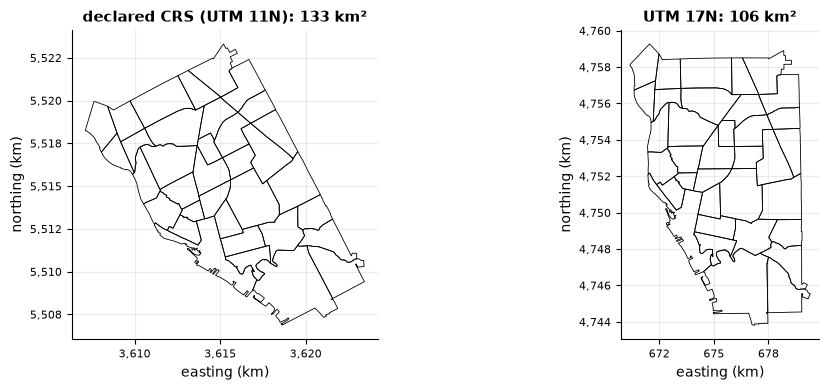

In [20]:
city_fixed = city.to_crs(4326).to_crs(26917)
crimes_fixed = crimes.to_crs(4326).to_crs(26917)

xy_f = np.column_stack([crimes_fixed.geometry.x, crimes_fixed.geometry.y])
k_fixed = (np.linalg.norm(xy_f[pairs[:, 0]] - xy_f[pairs[:, 1]], axis=1)[keep] / d_geo[keep]).mean()

fix = pd.DataFrame({
    "declared UTM 11N": [f"{k_measured:.4f}", f"{area_file:.1f}"],
    "re-projected to UTM 17N (EPSG:26917)": [f"{k_fixed:.4f}", f"{city_fixed.area.sum() / 1e6:.1f}"],
    "truth": ["1.0000", f"{area_attr:.1f}"],
}, index=["distance scale factor", "area (km²)"])
display(fix)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
km = lambda v, _: f"{v / 1000:,.0f}"
for a, (g, ttl) in zip(ax, [(city, f"declared CRS (UTM 11N): {area_file:.0f} km²"), (city_fixed, f"UTM 17N: {city_fixed.area.sum() / 1e6:.0f} km²")]):
    g.boundary.plot(ax=a, color="k", lw=0.6); a.set_title(ttl); a.set_aspect("equal")
    a.set_xlabel("easting (km)"); a.set_ylabel("northing (km)")
    a.xaxis.set_major_formatter(km); a.yaxis.set_major_formatter(km); a.tick_params(labelsize=8)
    a.xaxis.set_major_locator(plt.MaxNLocator(4))
plt.tight_layout(); plt.show()

Transverse Mercator is *conformal*, so every neighbourhood keeps its local shape; the whole map is merely turned and stretched. Seen on its own the left-hand map looks like a perfectly
reasonable Buffalo — it takes a side-by-side comparison, or a check of the numbers, to notice. **A wrong CRS can look right on a map; it shows up in the numbers.**
In section 0.9 the audit is packaged as a reusable function.

### Two more CRS failure modes

*Mismatched CRSs.* Coordinates in different systems are just different numbers; joining them "works" and returns nothing. *Missing CRS.* A file without a CRS
cannot be reprojected, and nothing tells you whether it is metres or degrees.

In [21]:
counties = ne                                            # CRS: EPSG:5070 (Albers, metres)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    joined = gpd.sjoin(crimes.head(200), counties)       # crimes: 'UTM 11N'  vs  counties: 'Albers'
print(f"spatial join of 200 crimes with counties in a different CRS -> {len(joined)} matches")
print("GeoPandas warned:", str(caught[0].message).splitlines()[0])

incidents = gpd.read_file(DATA / "Crime_Incidents_2018.shp")
print("\nCrime_Incidents_2018.shp has CRS:", incidents.crs)
print("its coordinates look like:", incidents.geometry.x.iloc[:2].round(3).tolist(), incidents.geometry.y.iloc[:2].round(3).tolist(),
      "-> plausibly degrees; the file also has 'longitude' / 'latitude' columns")
try:
    to_crs(incidents, 26917)
except ValueError as err:
    print("core.to_crs on a file with no CRS -> ValueError:", err)

same = np.allclose(incidents.geometry.x.astype(float), pd.to_numeric(incidents["longitude"], errors="coerce"), atol=1e-6, equal_nan=True)
if same:
    incidents = incidents.set_crs(4326)                   # only after checking, never blindly
    print("after verifying the coordinates equal the lon/lat columns, set_crs(4326) ->", incidents.crs.to_epsg())

spatial join of 200 crimes with counties in a different CRS -> 0 matches
GeoPandas warned: CRS mismatch between the CRS of left geometries and the CRS of right geometries.

Crime_Incidents_2018.shp has CRS: None
its coordinates look like: [-78.904, -78.848] [42.942, 42.898] -> plausibly degrees; the file also has 'longitude' / 'latitude' columns
core.to_crs on a file with no CRS -> ValueError: GeoDataFrame has no CRS set. Assign gdf.crs before reprojecting.
after verifying the coordinates equal the lon/lat columns, set_crs(4326) -> 4326


## 0.6 Distances

### Theory: what is a distance?

A function $d$ is a **metric** on locations if, for all $\mathbf{a},\mathbf{b},\mathbf{c}$:

1. $d(\mathbf{a},\mathbf{b})\ge 0$, and $d(\mathbf{a},\mathbf{b})=0 \iff \mathbf{a}=\mathbf{b}$;
2. $d(\mathbf{a},\mathbf{b})=d(\mathbf{b},\mathbf{a})$ (symmetry);
3. $d(\mathbf{a},\mathbf{c})\le d(\mathbf{a},\mathbf{b})+d(\mathbf{b},\mathbf{c})$ (triangle inequality).

For coordinates $\mathbf{a}=(a_1,a_2)$, $\mathbf{b}=(b_1,b_2)$ the **Minkowski** family is $d_p=\big(\sum_j |a_j-b_j|^p\big)^{1/p}$: $p=2$ is **Euclidean**
(straight line), $p=1$ is *Manhattan* (city blocks), $p\to\infty$ is *Chebyshev*. On the sphere the shortest path is a **great circle**.
Its length, from the **haversine formula** (Sinnott, 1984), with latitudes $\varphi_1,\varphi_2$ and longitudes $\lambda_1,\lambda_2$ (in radians), is
$$
a=\sin^2\!\frac{\varphi_2-\varphi_1}{2}+\cos\varphi_1\cos\varphi_2\,\sin^2\!\frac{\lambda_2-\lambda_1}{2},\qquad
d=2R\arcsin\sqrt{a},
$$
with the mean Earth radius $R=6371$ km. Treating the Earth as a sphere introduces an error of up to about $0.5\%$ against the exact **ellipsoidal geodesic** (Karney, 2013).

For $n$ locations the **distance matrix** $\mathbf{D}=(d_{ij})\in\mathbb{R}^{n\times n}$ is symmetric with a zero diagonal and needs $8n^2$ bytes in double precision.
Nearest-neighbour queries with a $k$-d tree need only $O(n\log n)$ time and $O(n)$ memory, so for large $n$ never build $\mathbf{D}$ unless you must.

### The functions

| Function | Purpose | Input order |
|---|---|---|
| `coords_from_geometry(geom)` | $(x,y)$ per feature (representative point for polygons) | — |
| `euclidean_distance_matrix(c)` | $n\times n$ Euclidean distances | $(x,y)$ |
| `euclidean_distances(a, b)` | rectangular $m\times n$ distances between two sets | $(x,y)$ |
| `haversine_distance_matrix(ll)` | great-circle distances in **km** | **(latitude, longitude)** |
| `pairwise_distances(c, metric)` | dispatcher: `euclidean`, `haversine`, `network`, or any SciPy metric | depends on metric |
| `normalize_coords(c)` | rescale each axis to $[0,1]$ | $(x,y)$ |

Note the input order of the haversine function: **latitude first**. Most spatial software, and GeoPandas, uses **(longitude, latitude) = (x, y)**. Mixing them up is a classic bug — quantified below.

In [22]:
from spatialstats.core import (coords_from_geometry, euclidean_distance_matrix, euclidean_distances,
                               haversine_distance_matrix, pairwise_distances, normalize_coords)

# Length of one degree of longitude at various latitudes: haversine vs the closed form (pi/180) R cos(phi)
R = 6371.0
lats = np.array([0, 20, 40, 45, 60, 80])
via_haversine = np.array([haversine_distance_matrix(np.array([[la, 0.0], [la, 1.0]]))[0, 1] for la in lats])
closed_form = np.pi / 180 * R * np.cos(np.radians(lats))
pd.DataFrame({"haversine (km)": via_haversine, "(π/180)·R·cos φ (km)": closed_form}, index=pd.Index(lats, name="latitude (°)")).round(3)

,haversine (km),(π/180)·R·cos φ (km)
latitude (°),,
0,111.195,111.195
20,104.489,104.489
40,85.180,85.180
45,78.626,78.627
60,55.597,55.597
80,19.309,19.309


### Five ways to measure the same distance

Four US city pairs — short to long — comparing the haversine function with the exact ellipsoidal geodesic and with Euclidean distance in a suitable projected CRS (CONUS Albers).

In [23]:
cities = {"New York": (40.7128, -74.0060), "Boston": (42.3601, -71.0589), "Atlanta": (33.7490, -84.3880),
          "Miami": (25.7617, -80.1918), "Seattle": (47.6062, -122.3321), "Denver": (39.7392, -104.9903)}
pairs_ = [("New York", "Boston"), ("New York", "Atlanta"), ("Atlanta", "Denver"), ("Miami", "Seattle")]
to_albers = Transformer.from_crs(4326, 5070, always_xy=True)

rows = []
for a, b in pairs_:
    (la1, lo1), (la2, lo2) = cities[a], cities[b]
    truth = geod.inv(lo1, la1, lo2, la2)[2] / 1000
    hav = haversine_distance_matrix(np.array([[la1, lo1], [la2, lo2]]))[0, 1]
    x1, y1 = to_albers.transform(lo1, la1); x2, y2 = to_albers.transform(lo2, la2)
    alb = np.hypot(x2 - x1, y2 - y1) / 1000
    swapped = haversine_distance_matrix(np.array([[lo1, la1], [lo2, la2]]))[0, 1]     # (lon, lat) passed by mistake
    rows.append({"pair": f"{a} – {b}", "geodesic (km)": truth, "haversine (km)": hav,
                 "haversine error (%)": 100 * (hav / truth - 1), "Albers Euclid. error (%)": 100 * (alb / truth - 1),
                 "lon/lat swapped error (%)": 100 * (swapped / truth - 1)})
pd.DataFrame(rows).set_index("pair").round(2)

,geodesic (km),haversine (km),haversine error (%),Albers Euclid. error (%),lon/lat swapped error (%)
pair,,,,,
New York – Boston,306.49,306.11,-0.12,-0.21,8.41
New York – Atlanta,1201.01,1200.32,-0.06,-0.15,-3.30
Atlanta – Denver,1950.89,1947.36,-0.18,-0.70,17.30
Miami – Seattle,4400.48,4396.10,-0.10,-0.12,5.06


The haversine formula stays within about a fifth of a percent here (its theoretical worst case is about half a percent). Euclidean distance in Albers stays within 1 %, but its error is
*not* a simple function of distance — it depends on where the pair sits relative to the projection's standard parallels (an equal-*area* projection makes no promise about distance).
Swapping latitude and longitude produces distances that are wrong by 3 % to 17 % here, in either direction — and no error message.

### Distance matrices for real data

We compute all $217\times 217$ distances between northeastern county coordinates two ways: Euclidean in the projected CRS (metres) and haversine on longitude/latitude,
and compare them pair by pair.

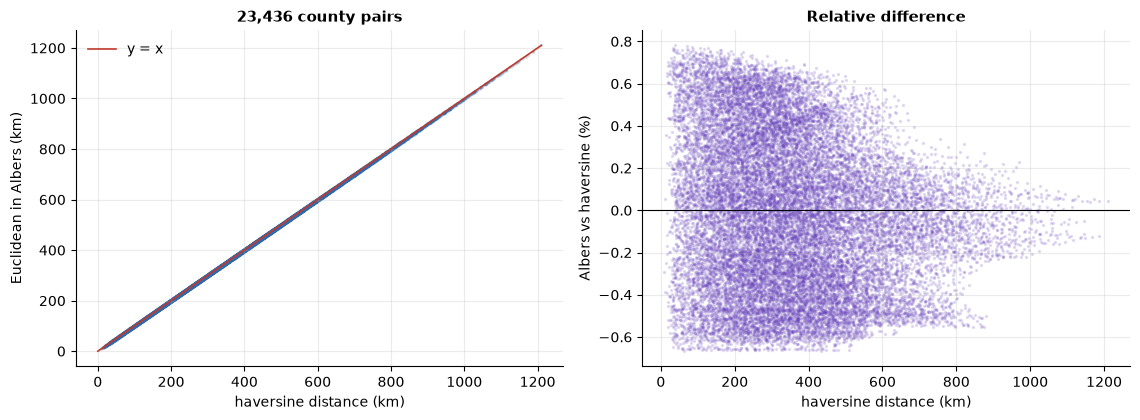

The two methods agree on average within **0.30%** (worst pair 0.78%). Median and maximum distance between two counties: 334 km, 1210 km.

In [24]:
xy_proj = coords_from_geometry(ne)                                                    # (x, y) in metres: one point per county
# transform *those same points* to lon/lat (a representative point is not invariant under reprojection,
# so calling coords_from_geometry() again on the lon/lat layer would pick different points)
lon, lat = Transformer.from_crs(ne.crs, 4326, always_xy=True).transform(xy_proj[:, 0], xy_proj[:, 1])
lat_lon = np.column_stack([lat, lon])                                                 # haversine wants (lat, lon)

D_eu = euclidean_distance_matrix(xy_proj) / 1000                                      # km
D_hv = pairwise_distances(lat_lon, metric="haversine")                                # km
iu = np.triu_indices(len(ne), k=1)
rel = 100 * (D_eu[iu] / D_hv[iu] - 1)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax[0].scatter(D_hv[iu], D_eu[iu], s=2, alpha=0.15, color=C["blue"])
mx = D_hv[iu].max()
ax[0].plot([0, mx], [0, mx], color=C["red"], lw=1.2, label="y = x")
ax[0].set(xlabel="haversine distance (km)", ylabel="Euclidean in Albers (km)", title=f"{len(iu[0]):,} county pairs"); ax[0].legend()
ax[1].scatter(D_hv[iu], rel, s=2, alpha=0.15, color=C["purple"])
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xlabel="haversine distance (km)", ylabel="Albers vs haversine (%)", title="Relative difference")
plt.tight_layout(); plt.show()

display(Markdown(f"The two methods agree on average within **{np.abs(rel).mean():.2f}%** (worst pair {np.abs(rel).max():.2f}%). "
                 f"Median and maximum distance between two counties: {np.median(D_hv[iu]):.0f} km, {D_hv[iu].max():.0f} km."))

### Do the numbers behave like a metric?

Distance matrices feed everything from spatial weights to kernel bandwidths, and a defective one produces silent nonsense. Two cheap sanity checks:
symmetry with a zero diagonal, and the triangle inequality on random triples.

In [25]:
rng = np.random.default_rng(0)
for name, D in [("Euclidean (Albers, km)", D_eu), ("haversine (km)", D_hv)]:
    i, j, k = rng.integers(0, len(D), size=(3, 20000))
    violation = D[i, k] - (D[i, j] + D[j, k])
    print(f"{name:24s} symmetric: {np.allclose(D, D.T)} | zero diagonal: {np.allclose(np.diag(D), 0)} | "
          f"min off-diagonal: {D[np.triu_indices(len(D), 1)].min():.3f} | worst triangle-inequality violation: {violation.max():.2e}")

Euclidean (Albers, km)   symmetric: True | zero diagonal: True | min off-diagonal: 9.293 | worst triangle-inequality violation: 0.00e+00
haversine (km)           symmetric: True | zero diagonal: True | min off-diagonal: 9.320 | worst triangle-inequality violation: 0.00e+00


### What does an $n\times n$ matrix cost?

Memory grows with $n^2$. The cell below measures the time and memory of a dense matrix, and the time of the alternative — asking a $k$-d tree for each point's 8 nearest neighbours.

In [26]:
from scipy.spatial import cKDTree

rng = np.random.default_rng(1)
rows = []
for n in [500, 1000, 2000, 3107, 4000]:
    pts = rng.random((n, 2)) * 1e5
    t0 = time.perf_counter(); D = euclidean_distance_matrix(pts); t_dense = time.perf_counter() - t0
    t0 = time.perf_counter(); cKDTree(pts).query(pts, k=9); t_tree = time.perf_counter() - t0
    rows.append({"n": n, "dense matrix (MB)": D.nbytes / 1e6, "dense time (s)": t_dense, "8-NN by k-d tree (s)": t_tree})
    del D
scale = pd.DataFrame(rows).set_index("n")
display(scale.round(3))
big = {"US counties": 3107, "Buffalo crimes": 14001, "CA PM2.5 station-days": 59566}
display(Markdown("**Dense-matrix footprint at real sizes:** " + "; ".join(f"{k} (n = {n:,}) → {8 * n * n / 1e9:.2f} GB" for k, n in big.items()) + "."))

,dense matrix (MB),dense time (s),8-NN by k-d tree (s)
n,,,
500,2.000,0.001,0.001
1000,8.000,0.002,0.001
2000,32.000,0.009,0.002
3107,77.228,0.021,0.003
4000,128.000,0.035,0.004


**Dense-matrix footprint at real sizes:** US counties (n = 3,107) → 0.08 GB; Buffalo crimes (n = 14,001) → 1.57 GB; CA PM2.5 station-days (n = 59,566) → 28.38 GB.

### Normalising coordinates — and a trap

`normalize_coords` rescales **each axis separately** to $[0,1]$: $x'=(x-x_{\min})/(x_{\max}-x_{\min})$, and likewise for $y$.
If the study area is not square this changes the geometry: distances after normalisation weight the two axes by $1/R_x$ and $1/R_y$ — for the US, whose extent is about 1.6 times wider than tall, one metre north counts 1.6 times as much as one metre east —
$$
d'(\mathbf{a},\mathbf{b})=\sqrt{\Big(\tfrac{\Delta x}{R_x}\Big)^2+\Big(\tfrac{\Delta y}{R_y}\Big)^2}\;\ne\;\frac{d(\mathbf{a},\mathbf{b})}{\text{const}}\quad\text{unless }R_x=R_y .
$$
Neighbours found on normalised coordinates are then *not* the nearest neighbours on the ground. Rescaling with **one common range** keeps distances proportional. The Northeast happens to be almost square, so the damage there is small; the elongated contiguous US shows what can go wrong.

In [27]:
def scaling_diagnostics(xy, region):
    rx, ry = np.ptp(xy[:, 0]), np.ptp(xy[:, 1])
    D0 = euclidean_distance_matrix(xy)
    iu_ = np.triu_indices(len(xy), k=1)
    A = D0.copy(); np.fill_diagonal(A, np.inf)
    rows = []
    for label, Z in [("normalize_coords (per axis)", normalize_coords(xy)),
                     ("single common range", (xy - xy.min(axis=0)) / max(rx, ry))]:
        Dn = euclidean_distance_matrix(Z)
        ratio = Dn[iu_] / D0[iu_]
        B = Dn.copy(); np.fill_diagonal(B, np.inf)
        rows.append({"region": region, "E-W / N-S extent": rx / ry, "scaling": label,
                     "corr with true distance": np.corrcoef(Dn[iu_], D0[iu_])[0, 1],
                     "distance ratio, max / min": ratio.max() / ratio.min(),
                     "same nearest neighbour (%)": 100 * np.mean(A.argmin(axis=1) == B.argmin(axis=1))})
    return rows

us_xy_ = pd.read_csv(DATA / "diabetes_usa.csv")[["X", "Y"]].to_numpy()
tab = pd.DataFrame(scaling_diagnostics(xy_proj, "Northeast (217 counties)") + scaling_diagnostics(us_xy_, "Contiguous US (3,107 counties)"))
tab.set_index(["region", "scaling"]).round(3)

E-W / N-S extent  \
region                         scaling                                         
Northeast (217 counties)       normalize_coords (per axis)             0.977   
                               single common range                     0.977   
Contiguous US (3,107 counties) normalize_coords (per axis)             1.619   
                               single common range                     1.619   

                                                            corr with true distance  \
region                         scaling                                                
Northeast (217 counties)       normalize_coords (per axis)                    1.000   
                               single common range                            1.000   
Contiguous US (3,107 counties) normalize_coords (per axis)                    0.956   
                               single common range                            1.000   

                                                            distance ratio, max / min  \
region                         scaling                                                  
Northeast (217 counties)       normalize_coords (per axis)                      1.023   
                               single common range                              1.000   
Contiguous US (3,107 counties) normalize_coords (per axis)                      1.619   
                               single common range                              1.000   

                                                            same nearest neighbour (%)  
region                         scaling                                                  
Northeast (217 counties)       normalize_coords (per axis)                      98.618  
                               single common range                             100.000  
Contiguous US (3,107 counties) normalize_coords (per axis)                      54.844  
                               single common range                             100.000

## 0.7 Datasets and the data catalogue

### What is in `data/`?

Instead of a hand-written list (which goes stale), the next cell **inspects every file** and builds the catalogue. The `CRS` column is what the file *declares* — as section 0.5 showed, declaring is not the same as being right.

In [28]:
def describe(path: Path, layer=None):
    ext = path.suffix.lower()
    if ext in {".shp", ".gpkg"}:
        g = gpd.read_file(path, layer=layer) if layer else gpd.read_file(path)
        crs = g.crs
        crs_txt = "none" if crs is None else (f"EPSG:{crs.to_epsg()}" if crs.to_epsg() else crs.name)
        kinds = "/".join(sorted(g.geom_type.unique()))
        cols = [c for c in g.columns if c != "geometry"]
        return dict(file=path.name + (f"[{layer}]" if layer else ""), kind="vector", rows=len(g), geometry=kinds, CRS=crs_txt, columns=len(cols),
                    fields=", ".join(cols[:6]) + (" …" if len(cols) > 6 else ""))
    if ext == ".csv":
        d = pd.read_csv(path)
        return dict(file=path.name, kind="table", rows=len(d), geometry="—", CRS="—", columns=d.shape[1],
                    fields=", ".join(d.columns[:6]) + (" …" if d.shape[1] > 6 else ""))

files = sorted(p for p in DATA.iterdir() if p.suffix.lower() in {".shp", ".csv", ".gpkg"})
records = []
for p in files:
    if p.suffix.lower() == ".gpkg":                       # a GeoPackage can hold several layers
        records += [describe(p, layer=name) for name in gpd.list_layers(p)["name"]]
    else:
        records.append(describe(p))
catalogue = pd.DataFrame(records).set_index("file")
catalogue

,kind,rows,geometry,CRS,columns,fields
file,,,,,,
CA_pm25_2025.csv,table,59566,—,—,8,"Site ID, State, County, Lat, Long, Date …"
CA_pm25_grid_predictions.csv,table,196764,—,—,6,"x, y, month, month_name, pm25_pred, pm25_sd"
COUNTY_ATLANTIC.shp,vector,666,MultiPolygon/Polygon,EPSG:5070,13,"ID, ID2, FIPS, x, y, REGION_ID …"
COUNTY_NORTHEAST.shp,vector,217,MultiPolygon/Polygon,EPSG:5070,11,"FIPS, x, y, REGION_ID, DIVISION_I, STATE_ID …"
Crime_Incidents_2018.shp,vector,14036,Point,none,12,"ID2, address_1, date_creat, day_of_wee, hour_o..."
Crime_location_2018.shp,vector,14001,Point,EPSG:3718,1,ID
US_COUNTY.shp,vector,3108,MultiPolygon/Polygon,EPSG:5070,11,"FIPS, x, y, REGION_ID, DIVISION_I, STATE_ID …"
buffalo_city.shp,vector,35,Polygon,EPSG:3718,11,"calcacres, nbhdname, nbhdnum, objectid, object..."
cancer_areas.shp,vector,217,MultiPolygon/Polygon,Lambert_Conformal_Conic,2,"FIPS, rate"


Things the catalogue makes visible:

* Several files exist **twice** — as a shapefile and a CSV (`diabetes_*`) — with **different column names** (`Dia_pct` vs `Diabetes_per`, `x` vs `X`).
* CRSs are **not uniform** across files, and one file (`Crime_Incidents_2018.shp`) has none. Harmonise before combining layers.
* `cancer_areas.shp` declares a custom *Lambert conformal conic* with no EPSG code; that is legal, but you cannot refer to it by number.

### Synthetic datasets with known truth

Real data never tell you the right answer. For learning (and for testing a method) a **synthetic dataset with known structure** is invaluable.
`load_lattice(n)` returns an $n\times n$ grid of square cells with the spatially structured attribute
$$
z(x,y)=\sin\!\Big(\frac{2\pi x}{n}\Big)+\cos\!\Big(\frac{2\pi y}{n}\Big)+\varepsilon,\qquad \varepsilon\sim N(0,\,0.3^2),
$$
plus a binary variable, $1[z>\operatorname{median}(z)]$. The smooth part is a known spatial trend, so a good autocorrelation statistic *must* detect it.
`load_points_csr(n)` draws a *complete spatial randomness* pattern — the null model of Chapter 1.

load_lattice   -> GeoDataFrame (144, 7) | columns: ['row', 'col', 'x', 'y', 'z', 'binary']
load_points_csr -> GeoDataFrame (150, 3)


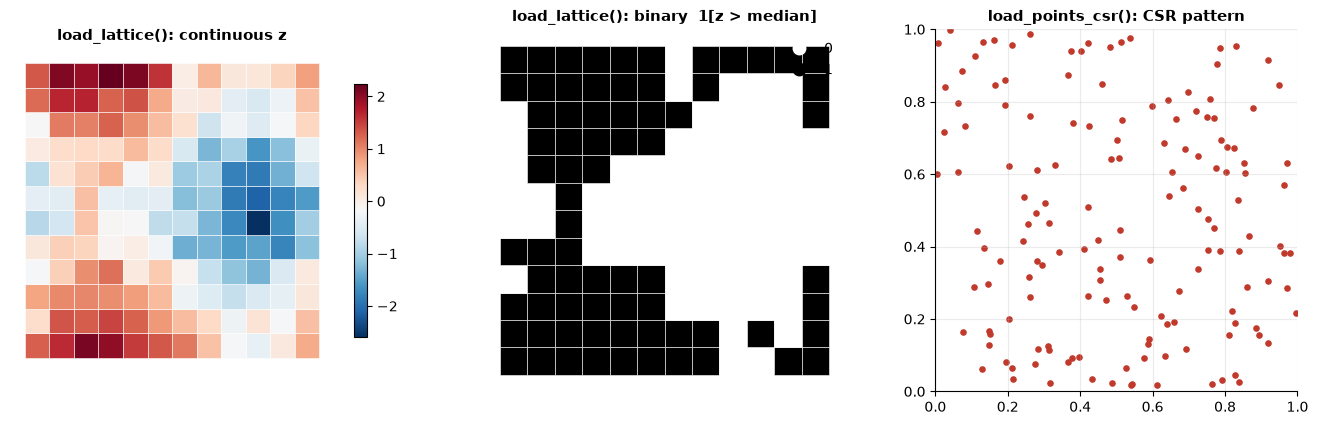

In [29]:
from spatialstats.datasets import load_lattice, load_points_csr

lattice, zcol = load_lattice(n=12, seed=0)
pts_csr, _ = load_points_csr(n=150, seed=1)
print("load_lattice   ->", type(lattice).__name__, lattice.shape, "| columns:", [c for c in lattice.columns if c != "geometry"])
print("load_points_csr ->", type(pts_csr).__name__, pts_csr.shape)

fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))
lattice.plot(ax=ax[0], column="z", cmap="RdBu_r", edgecolor="white", linewidth=0.4, legend=True, legend_kwds={"shrink": 0.7})
ax[0].set_title("load_lattice(): continuous z")
lattice.plot(ax=ax[1], column="binary", cmap="Greys", edgecolor="white", linewidth=0.4, categorical=True, legend=True)
ax[1].set_title("load_lattice(): binary  1[z > median]")
ax[2].scatter(pts_csr.geometry.x, pts_csr.geometry.y, s=14, color=C["red"])
ax[2].set(xlim=(0, 1), ylim=(0, 1), aspect="equal", title="load_points_csr(): CSR pattern")
for a in ax[:2]:
    a.set_axis_off()
plt.tight_layout(); plt.show()

### A warning about the four "GW" loaders

`load_georgia`, `load_londonhouse`, `load_beijing_pm25` and `load_ncovid` have names of real datasets, but they are **simulated**. Their docstrings say so, and the numbers show it.

In [30]:
from spatialstats import datasets as ds
from spatialstats.gwmodel import datasets as gw_ds      # the wrappers in `datasets` carry no docstring; the originals do

for name in ["load_georgia", "load_londonhouse", "load_beijing_pm25", "load_ncovid"]:
    print(f"{name:18s}: {inspect.getdoc(getattr(gw_ds, name)).splitlines()[0]}")

gdf_g, features, target = ds.load_georgia()
print(f"\nload_georgia returned {len(gdf_g)} points; longitude range {gdf_g.x.min():.2f} to {gdf_g.x.max():.2f}, "
      f"latitude {gdf_g.y.min():.2f} to {gdf_g.y.max():.2f}; features = {features}, target = {target!r}")
print("The locations are uniform random points in a box, not the 159 Georgia county centroids.")

load_georgia      : Simulated Georgia (USA) educational attainment dataset.
load_londonhouse  : Simulated London house prices dataset.
load_beijing_pm25 : Simulated Beijing PM2.5 dataset with meteorological covariates.
load_ncovid       : Simulated US county COVID mortality dataset for GTNNWR demonstration.

load_georgia returned 159 points; longitude range -85.58 to -80.81, latitude 30.45 to 34.96; features = ['PctRural', 'PctBach', 'PctEld', 'PctFB', 'PctPov', 'PctBlack'], target = 'TotPop90'
The locations are uniform random points in a box, not the 159 Georgia county centroids.


Use them to try out an API; never quote results from them as if they were about real places. Real data live in `data/`.

### Data hygiene: three traps in the bundled files

**1. Key columns.** County codes (FIPS) identify a county across tables, but their *type* varies from file to file.

In [31]:
us_csv = pd.read_csv(DATA / "diabetes_usa.csv")
us_shp = gpd.read_file(DATA / "US_COUNTY.shp")
cancer_areas = gpd.read_file(DATA / "cancer_areas.shp")
cancer_pts = pd.read_csv(DATA / "cancer_points.csv")

print(pd.DataFrame({"FIPS dtype": [us_csv.FIPS.dtype, us_shp.FIPS.dtype, cancer_areas.FIPS.dtype, cancer_pts.FIPS.dtype]},
                   index=["diabetes_usa.csv", "US_COUNTY.shp", "cancer_areas.shp", "cancer_points.csv"]).astype(str).to_string())

# numeric keys: pandas happily joins int64 with float64 ...
m1 = us_csv.merge(us_shp[["FIPS", "STATE"]], on="FIPS")
m2 = cancer_areas.merge(cancer_pts.groupby("FIPS", as_index=False)["POP10"].sum(), on="FIPS")
print(f"\nnumeric merge  csv x shp: {len(m1)} rows | areas x points: {len(m2)} rows  (both succeed)")

# ... but string keys built from floats do not match, and leading zeros were lost upstream
as_text = lambda s: s.astype(str)
v = cancer_pts.FIPS.iloc[0]
print("string keys    areas ∩ points:", len(set(as_text(cancer_areas.FIPS)) & set(as_text(cancer_pts.FIPS))),
      f"matching keys, although the numeric overlap is {len(set(cancer_areas.FIPS) & set(cancer_pts.FIPS))}: the same county is "
      f"'{int(v)}' in one file and '{v}' in the other")
print("lowest FIPS in the file:", us_csv.FIPS.min(), "-> the real code for Alabama's Autauga County is '01001'")

fips5 = lambda s: s.astype("int64").astype(str).str.zfill(5)         # the safe canonical key
print("canonical 5-digit string key:", fips5(us_csv.FIPS).iloc[:3].tolist(), "| unique in csv:", fips5(us_csv.FIPS).is_unique)

                  FIPS dtype
diabetes_usa.csv       int64
US_COUNTY.shp        float64
cancer_areas.shp       int64
cancer_points.csv    float64

numeric merge  csv x shp: 3107 rows | areas x points: 217 rows  (both succeed)
string keys    areas ∩ points: 0 matching keys, although the numeric overlap is 217: the same county is '42049' in one file and '42049.0' in the other
lowest FIPS in the file: 1001 -> the real code for Alabama's Autauga County is '01001'
canonical 5-digit string key: ['01001', '01003', '01005'] | unique in csv: True


**2. Categorical columns stored as text.** Regression needs numbers; `UrbRural` holds the strings `"Urban"` / `"Rural"` and must be coded before it goes into a design matrix (Chapters 3 and 6).

**3. Duplicate locations.** Geocoded events pile up on street addresses; point-pattern statistics assume distinct locations (Chapter 1).

In [32]:
print("UrbRural values:", ne["UrbRural"].value_counts().to_dict(), "-> dummy:", "(ne.UrbRural == 'Urban').astype(float)")
ne["Urban"] = (ne["UrbRural"] == "Urban").astype(float)

xy_c = np.column_stack([crimes.geometry.x, crimes.geometry.y])
n_unique = len(np.unique(xy_c, axis=0))
display(Markdown(f"**Crime locations:** {len(xy_c):,} events but only {n_unique:,} distinct coordinates — "
                 f"{100 * (1 - n_unique / len(xy_c)):.0f}% of events share a location with an earlier event."))

UrbRural values: {'Urban': 176, 'Rural': 41} -> dummy: (ne.UrbRural == 'Urban').astype(float)


**Crime locations:** 14,001 events but only 8,933 distinct coordinates — 36% of events share a location with an earlier event.

## 0.8 First maps with `spatialstats.viz`

### Theory: turning numbers into classes

A **choropleth** colours each area by its value. With continuous data it is usually clearer to group values into $k$ classes with breakpoints $b_0<b_1<\dots<b_k$ and give each class one colour. How to choose the breaks is a modelling decision:

* **Quantiles**: $b_j=Q(j/k)$, the $j/k$ sample quantile. Every class holds about $n/k$ areas; the map is always "balanced" but breaks may split similar values.
* **Equal interval**: $b_j=x_{\min}+j\,\dfrac{x_{\max}-x_{\min}}{k}$. Easy to read; wasteful for skewed data (most areas fall in one or two classes).
* **Natural breaks (Fisher–Jenks)**: choose breaks to minimise the within-class sum of squared deviations,
$$
\text{SDCM}=\sum_{c=1}^{k}\;\sum_{i\in C_c}\big(x_i-\bar x_c\big)^2 .
$$
  The exact optimum is found by dynamic programming (Fisher, 1958; Jenks, 1967).

Classifications can be compared with the **goodness of variance fit**
$$
\text{GVF}=1-\frac{\text{SDCM}}{\text{SDAM}},\qquad \text{SDAM}=\sum_{i=1}^{n}(x_i-\bar x)^2 ,
$$
the share of total variation explained by the classes ($0\le\text{GVF}\le1$). By construction Fisher–Jenks maximises GVF for a given $k$; GVF rises with $k$ with diminishing returns, so pick $k$ near the elbow — and since readers can rarely tell more than 5–7 shades apart reliably, $k\le 7$ is a sensible ceiling.

The package's `choropleth(gdf, column, scheme, k, ...)` accepts `'quantiles'`, `'equal_interval'` and `'natural_breaks'`.

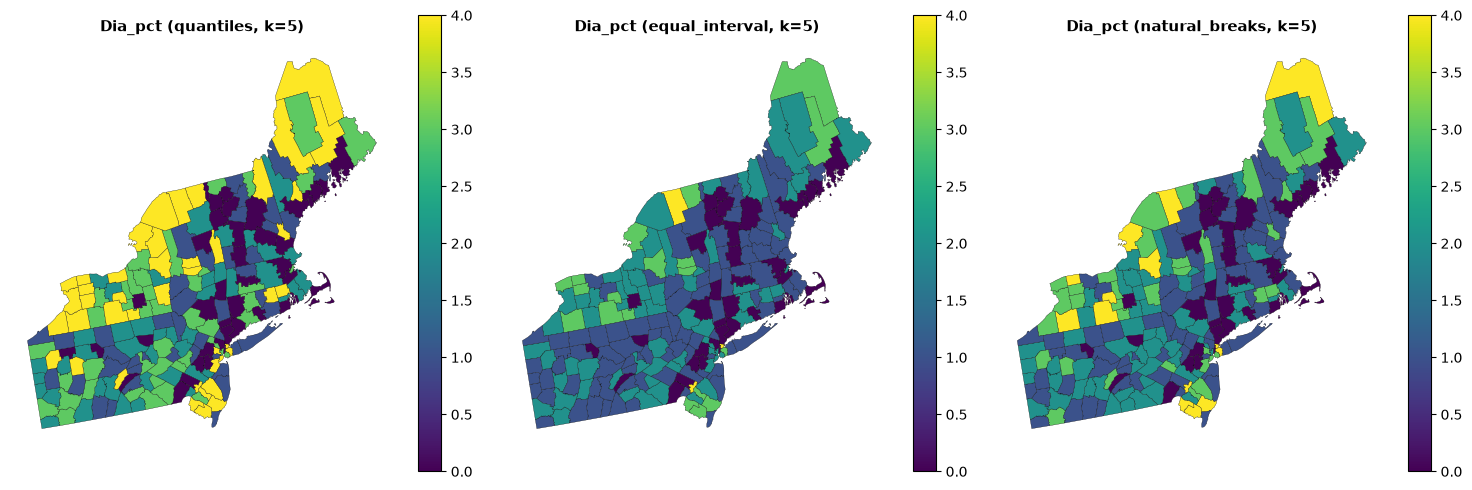

In [33]:
from spatialstats.viz import choropleth

schemes = ["quantiles", "equal_interval", "natural_breaks"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, scheme in zip(axes, schemes):
    choropleth(ne, "Dia_pct", scheme=scheme, k=5, ax=ax, cmap="viridis")
plt.tight_layout(); plt.show()

Same variable, three impressions. The colour bar of this function runs over the class **index** (0–4), not over data values, so to see what the classes *mean* we compute the breaks with `mapclassify` (the library the package delegates to), together with the histogram they cut.

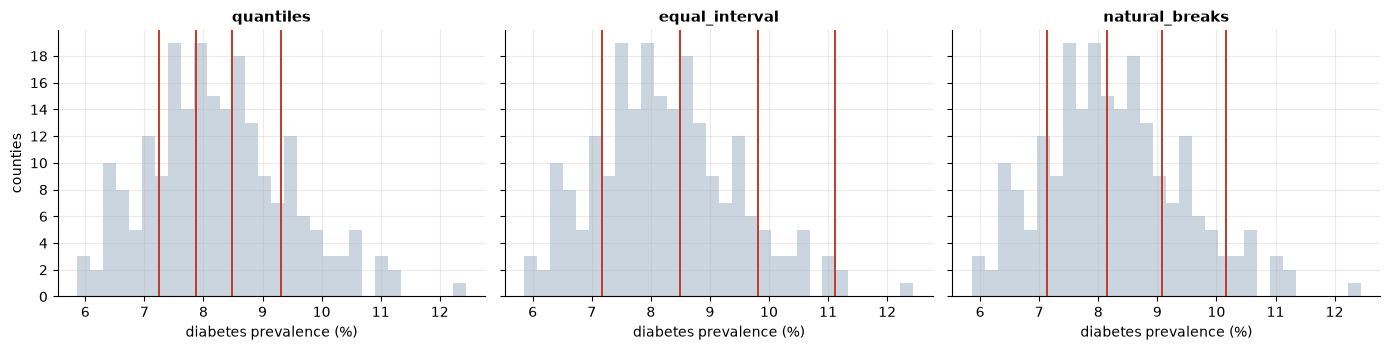

,quantiles,equal_interval,natural_breaks
class 1 upper bound,7.24,7.18,7.14
class 2 upper bound,7.87,8.49,8.14
class 3 upper bound,8.48,9.81,9.08
class 4 upper bound,9.32,11.12,10.16
class 5 upper bound,12.44,12.44,12.44
counts per class,"[44, 43, 43, 44, 43]","[40, 90, 65, 19, 3]","[38, 71, 60, 34, 14]"


In [34]:
import mapclassify

y = ne["Dia_pct"].to_numpy()
classifiers = {"quantiles": mapclassify.Quantiles(y, k=5), "equal_interval": mapclassify.EqualInterval(y, k=5),
               "natural_breaks": mapclassify.FisherJenks(y, k=5)}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, (name, cl) in zip(axes, classifiers.items()):
    ax.hist(y, bins=30, color="#cbd5e0")
    for b in cl.bins[:-1]:
        ax.axvline(b, color=C["red"], lw=1.4)
    ax.set_title(name); ax.set_xlabel("diabetes prevalence (%)")
axes[0].set_ylabel("counties")
axes[0].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

breaks = pd.DataFrame({n: np.round(cl.bins, 2) for n, cl in classifiers.items()}, index=[f"class {i + 1} upper bound" for i in range(5)])
breaks.loc["counts per class"] = [str(cl.counts.tolist()) for cl in classifiers.values()]
breaks

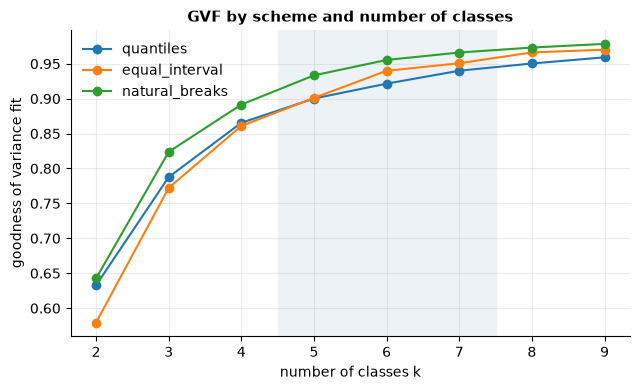

,quantiles,equal_interval,natural_breaks
k,,,
3,0.788,0.772,0.824
5,0.900,0.901,0.933
7,0.940,0.951,0.966


Fisher–Jenks has the highest GVF at every $k$, as theory requires (checked by an assertion in this cell).

In [35]:
def gvf(values, labels):
    sdcm = sum(((values[labels == c] - values[labels == c].mean()) ** 2).sum() for c in np.unique(labels))
    return 1 - sdcm / ((values - values.mean()) ** 2).sum()

ks = range(2, 10)
curve = {name: [gvf(y, getattr(mapclassify, cls)(y, k=k).yb) for k in ks]
         for name, cls in [("quantiles", "Quantiles"), ("equal_interval", "EqualInterval"), ("natural_breaks", "FisherJenks")]}
gvf_table = pd.DataFrame(curve, index=pd.Index(list(ks), name="k"))

fig, ax = plt.subplots(figsize=(6.5, 4))
for name, vals in curve.items():
    ax.plot(list(ks), vals, marker="o", label=name)
ax.axvspan(4.5, 7.5, color="#edf2f7", zorder=0)
ax.set(xlabel="number of classes k", ylabel="goodness of variance fit", title="GVF by scheme and number of classes")
ax.legend(); plt.tight_layout(); plt.show()

display(gvf_table.loc[[3, 5, 7]].round(3))
assert (gvf_table["natural_breaks"] >= gvf_table[["quantiles", "equal_interval"]].max(axis=1) - 1e-9).all()
display(Markdown("Fisher–Jenks has the highest GVF at every $k$, as theory requires (checked by an assertion in this cell)."))

### A silent fallback worth knowing about

`spatialstats.viz` delegates classification to `mapclassify` when it is installed. If it is **not**, the package falls back to a simple quantile rule —
**for all three schemes that need it, including "natural breaks"** — without any warning. We can prove this by hiding `mapclassify` from the import system for a moment:

In [36]:
from spatialstats.viz.choropleth import _classify

saved = sys.modules.get("mapclassify")
sys.modules["mapclassify"] = None                 # makes "import mapclassify" raise ImportError
try:
    fallback_nb = _classify(y, "natural_breaks", 5)
    fallback_q = _classify(y, "quantiles", 5)
finally:
    sys.modules["mapclassify"] = saved

with_mc_nb = _classify(y, "natural_breaks", 5)
print("without mapclassify: 'natural_breaks' identical to 'quantiles'? ->", np.array_equal(fallback_nb, fallback_q))
print("with mapclassify   : 'natural_breaks' identical to 'quantiles'? ->", np.array_equal(with_mc_nb, _classify(y, "quantiles", 5)))
print(f"GVF actually achieved: fallback {gvf(y, fallback_nb):.3f} vs real Fisher-Jenks {gvf(y, with_mc_nb):.3f}")

without mapclassify: 'natural_breaks' identical to 'quantiles'? -> True
with mapclassify   : 'natural_breaks' identical to 'quantiles'? -> False
GVF actually achieved: fallback 0.900 vs real Fisher-Jenks 0.933


So a map titled "natural breaks" made in an environment without the `viz` extra is really a quantile map. Install `pyspatialstats[viz]` (it includes `mapclassify`) and check it as in section 0.1.

### Maps can mislead: counts versus rates

An area with more people has more cases *even if its risk is identical*. A map of raw counts therefore mostly draws the population; a map of rates (cases per person) draws the risk. Compare:

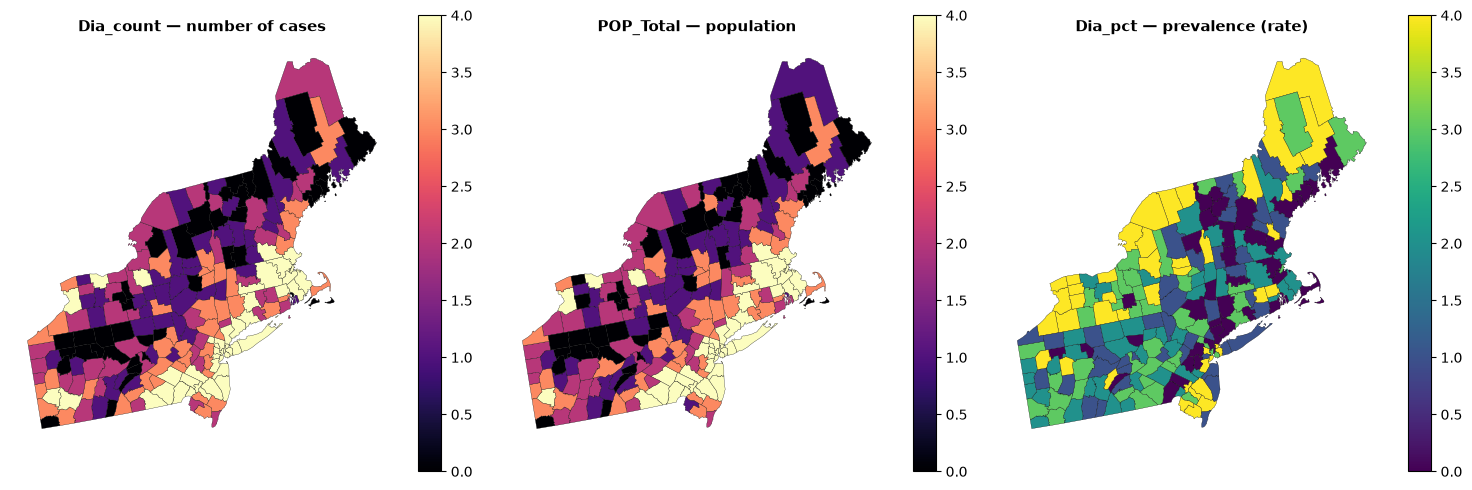

Correlation with population: cases **0.983**, prevalence **0.092**. The count map is essentially a map of where people live. Chapter 5 shows a second problem with maps of rates: rates from *small* populations are noisy, and the most extreme values tend to come from the smallest areas.

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
choropleth(ne, "Dia_count", scheme="quantiles", k=5, ax=axes[0], cmap="magma")
axes[0].set_title("Dia_count — number of cases")
choropleth(ne, "POP_Total", scheme="quantiles", k=5, ax=axes[1], cmap="magma")
axes[1].set_title("POP_Total — population")
choropleth(ne, "Dia_pct", scheme="quantiles", k=5, ax=axes[2], cmap="viridis")
axes[2].set_title("Dia_pct — prevalence (rate)")
plt.tight_layout(); plt.show()

r_counts = np.corrcoef(ne["Dia_count"], ne["POP_Total"])[0, 1]
r_rate = np.corrcoef(ne["Dia_pct"], ne["POP_Total"])[0, 1]
display(Markdown(f"Correlation with population: cases **{r_counts:.3f}**, prevalence **{r_rate:.3f}**. "
                 "The count map is essentially a map of where people live. Chapter 5 shows a second problem with maps of rates: "
                 "rates from *small* populations are noisy, and the most extreme values tend to come from the smallest areas."))

### First look, then measure

Look at the prevalence map once more. The high values are not scattered at random; they gather in some parts of the region.
That impression — *nearby areas look alike* — is exactly what **Tobler's first law of geography** states ("everything is related to everything else, but near things are more related than distant things", Tobler, 1970).
An impression is not evidence. Building the neighbour structure $\mathbf{W}$ and testing it with Moran's $I$ is the subject of **Chapter 2**.

## 0.9 Putting it together: a reproducible loading recipe

Everything in this chapter can be turned into a **checklist that runs automatically**. The function below audits a layer — CRS present? metric? appropriate for the location?
geometries valid? duplicates? — and `load_study_area` wraps the audit around loading and reprojection, returning a `SpatialData` and a report.
Use it (or something like it) as the first step of every analysis; it takes seconds and would have caught the Buffalo problem immediately.

In [38]:
def crs_audit(gdf, name="layer"):
    """Return a DataFrame of data-quality checks for a GeoDataFrame."""
    rows = []
    add = lambda check, status, detail: rows.append({"check": check, "status": status, "detail": detail})
    crs = gdf.crs
    if crs is None:
        add("CRS declared", "FAIL", "no CRS: cannot reproject and units are unknown")
    else:
        add("CRS declared", "ok", crs.name)
        unit = crs.axis_info[0].unit_name
        add("metric projected CRS", "ok" if crs.is_projected and unit == "metre" else "warn",
            f"{'geographic' if crs.is_geographic else 'projected'}, unit = {unit}")
        if crs.area_of_use is not None:
            pts = gdf.geometry.representative_point()
            if crs.is_geographic:
                lon, lat = pts.x.to_numpy(), pts.y.to_numpy()
            else:
                lon, lat = Transformer.from_crs(crs, 4326, always_xy=True).transform(pts.x.to_numpy(), pts.y.to_numpy())
            w, s, e, n = crs.area_of_use.bounds
            in_lon = (lon >= w) & (lon <= e) if w <= e else (lon >= w) | (lon <= e)
            frac = float(np.mean(in_lon & (lat >= s) & (lat <= n)))
            deg = lambda v, pos, neg: f"{abs(v):.0f}°{pos if v >= 0 else neg}"
            add("inside the CRS's area of use", "ok" if frac > 0.99 else "FAIL",
                f"{100 * frac:.0f}% of features; CRS is for {deg(w, 'E', 'W')} to {deg(e, 'E', 'W')}, "
                f"data at {abs(np.median(lon)):.1f}°{'E' if np.median(lon) >= 0 else 'W'}, {abs(np.median(lat)):.1f}°{'N' if np.median(lat) >= 0 else 'S'}")
    bad = int((~gdf.geometry.is_valid).sum()); empty = int(gdf.geometry.is_empty.sum()); miss = int(gdf.geometry.isna().sum())
    add("valid, non-empty geometries", "ok" if bad + empty + miss == 0 else "warn", f"{bad} invalid, {empty} empty, {miss} missing")
    types = gdf.geom_type.value_counts().to_dict()
    add("geometry types", "ok" if len(types) == 1 else "note", str(types))
    dup = int(gdf.geometry.to_wkb().duplicated().sum())
    add("repeated geometries", "ok" if dup == 0 else "note", f"{dup} of {len(gdf)} features repeat an earlier geometry")
    add("unique index", "ok" if gdf.index.is_unique else "warn", f"{int(gdf.index.duplicated().sum())} duplicated index labels")
    return pd.DataFrame(rows).set_index("check")


def load_study_area(source, y=None, X=None, target_crs=None):
    """Load, audit and (optionally) reproject a layer. Returns (SpatialData, audit DataFrame)."""
    gdf = source if isinstance(source, gpd.GeoDataFrame) else gpd.read_file(source)
    report = crs_audit(gdf)
    roles = ([y] if isinstance(y, str) else list(y or [])) + list(X or [])
    n_missing = {c: int(gdf[c].isna().sum()) for c in roles}
    report.loc["no missing values in roles"] = ("ok" if not any(n_missing.values()) else "warn",
                                                 str(n_missing) if roles else "no roles assigned")
    if target_crs is not None:
        if gdf.crs is None:
            report.loc["reprojection"] = ("FAIL", "skipped: layer has no CRS")
        else:
            gdf = to_crs(gdf, target_crs)
            report.loc["reprojection"] = ("ok", f"-> EPSG:{gdf.crs.to_epsg()}")
    return SpatialData(gdf, y=y, X=X), report


def show(report):
    colour = {"ok": "#c6f6d5", "note": "#fefcbf", "warn": "#feebc8", "FAIL": "#fed7d7"}
    return report.style.map(lambda v: f"background-color: {colour.get(v, '')}", subset=["status"])

_, rep_ne = load_study_area(DATA / "diabetes_northeast.shp", y="Dia_pct", X=["Obesity", "PhysInact", "SVI"])
display(Markdown("**diabetes_northeast.shp** — the well-behaved case"))
show(rep_ne)

**diabetes_northeast.shp** — the well-behaved case

,status,detail
check,,
CRS declared,ok,NAD83 / Conus Albers
metric projected CRS,ok,"projected, unit = metre"
inside the CRS's area of use,ok,"100% of features; CRS is for 125°W to 67°W, data at 74.7°W, 41.8°N"
"valid, non-empty geometries",ok,"0 invalid, 0 empty, 0 missing"
geometry types,note,"{'Polygon': 206, 'MultiPolygon': 11}"
repeated geometries,ok,0 of 217 features repeat an earlier geometry
unique index,ok,0 duplicated index labels
no missing values in roles,ok,"{'Dia_pct': 0, 'Obesity': 0, 'PhysInact': 0, 'SVI': 0}"


In [39]:
_, rep_buf = load_study_area(DATA / "Crime_location_2018.shp")
display(Markdown("**Crime_location_2018.shp** — a valid CRS, wrong for the place"))
display(show(rep_buf))

_, rep_inc = load_study_area(DATA / "Crime_Incidents_2018.shp", target_crs=26917)
display(Markdown("**Crime_Incidents_2018.shp** — no CRS at all"))
show(rep_inc)

**Crime_location_2018.shp** — a valid CRS, wrong for the place

,status,detail
check,,
CRS declared,ok,NAD83(NSRS2007) / UTM zone 11N
metric projected CRS,ok,"projected, unit = metre"
inside the CRS's area of use,FAIL,"0% of features; CRS is for 120°W to 114°W, data at 78.8°W, 42.9°N"
"valid, non-empty geometries",ok,"0 invalid, 0 empty, 0 missing"
geometry types,ok,{'Point': 14001}
repeated geometries,note,5068 of 14001 features repeat an earlier geometry
unique index,ok,0 duplicated index labels
no missing values in roles,ok,no roles assigned


**Crime_Incidents_2018.shp** — no CRS at all

,status,detail
check,,
CRS declared,FAIL,no CRS: cannot reproject and units are unknown
"valid, non-empty geometries",ok,"0 invalid, 0 empty, 0 missing"
geometry types,ok,{'Point': 14036}
repeated geometries,note,5087 of 14036 features repeat an earlier geometry
unique index,ok,0 duplicated index labels
no missing values in roles,ok,no roles assigned
reprojection,FAIL,skipped: layer has no CRS


The recipe flags what a human eye cannot see on a map: the Buffalo file outside its CRS's zone, and the incident file without any CRS (and therefore un-reprojectable).
Note too the "repeated geometries" line for crimes — the duplicate-location problem of section 0.7.

## 0.10 Common pitfalls

| Pitfall | Symptom | Guard |
|---|---|---|
| Geographic (lon/lat) coordinates used with a distance method | Bandwidths in degrees; distortion of tens of percent | `is_projected` check; `ensure_projected(..., target_crs=...)` with a suitable CRS |
| CRS valid but wrong for the location (§0.5) | Areas and distances biased with no error | Compare data location with `crs.area_of_use`; `crs_audit` |
| CRS missing or different between layers | Empty spatial joins; nonsense overlays | Check `.crs` of every layer; `to_crs` to one common CRS |
| Web Mercator (3857) used for measurement | Areas inflated by $\sec^2\varphi$ | Equal-area / local metric CRS |
| `(lat, lon)` vs `(lon, lat)` order (§0.6) | Silently wrong haversine distances | Remember: haversine takes *latitude first*, GeoPandas is *(x, y)* |
| Centroid assumed = `coords_array()` (§0.4) | Km-scale location differences | Set the `coords` role explicitly |
| Per-axis coordinate normalisation (§0.6) | Distorted neighbourhoods | Scale with one common range |
| Dense $n\times n$ distance matrix on large $n$ | Memory errors | k-d tree / sparse weights |
| Keys as floats or strings (§0.7) | Joins with zero matches; lost leading zeros | Canonical 5-digit string key |
| `natural_breaks` without `mapclassify` (§0.8) | Quantile map with the wrong title | Install the `viz` extra; verify |
| Mapping counts instead of rates (§0.8) | Map reproduces population | Use rates; small-area smoothing (Chapter 5) |
| Simulated "real-looking" datasets (§0.7) | Results reported as if about real places | Read docstrings; use `data/` for real work |

## 0.11 Exercises

Try each before opening the solutions cell that follows.

1. **A third CRS.** Build a `SpatialData` from `crime_data_2018.csv` using its `long`/`lat` columns (`from_frame`), project it to UTM 17N (EPSG:26917), and compute the average ratio of inter-point distances to those in the shapefile's declared CRS. What would `ensure_projected()` with its *default* target give instead, and why is it also unsuitable?
2. **Scaling up.** How much memory would a dense distance matrix for all 3,107 US counties need (`diabetes_usa.csv`, columns `X`, `Y`)? Compute the 8 nearest neighbours of each county instead and report how long it takes.
3. **Skew.** `POP_Total` is strongly right-skewed. Compare quantile and equal-interval classification of `POP_Total` for $k=5$: how many counties fall in each class, and what is each scheme's GVF? Does a $\log$ transform change the answer? Is the highest GVF always the best map?
4. **Choosing a projection.** The California PM2.5 stations were plotted in CONUS Albers (5070). Re-project them to *California Albers* (EPSG:3310) and measure how the distance between the two most distant stations differs. Which CRS would you choose for a kriging analysis of California, and why?
5. **Which data type?** For each — (i) wildfire ignition points in 2020, (ii) tract-level asthma rates, (iii) hourly ozone at 60 monitors, (iv) county unemployment — name the data type (§0.3), the quantity of interest, and the chapter that treats it.

### Solutions

In [40]:
# --- Exercise 1 -----------------------------------------------------------------------------
sd_csv = SpatialData.from_frame(crime_tbl, x_col="long", y_col="lat", crs=4326)
sd_17 = sd_csv.to_crs(26917)
# from_frame() set coords=['long','lat'] and to_crs() does not touch those columns (the trap of section 0.4),
# so take the coordinates from the GEOMETRY of the reprojected layer:
xy_of = lambda obj: np.column_stack([obj.gdf.geometry.x, obj.gdf.geometry.y])
c17 = xy_of(sd_17)
c11 = np.column_stack([crimes.geometry.x, crimes.geometry.y])              # declared UTM 11N
ii, jj = pairs[keep, 0], pairs[keep, 1]                                  # the pairs used in section 0.5 (> 100 m apart)
ratio = (np.linalg.norm(c11[ii] - c11[jj], axis=1) / np.linalg.norm(c17[ii] - c17[jj], axis=1)).mean()
c3857 = xy_of(sd_csv.ensure_projected())
ratio_3857 = (np.linalg.norm(c3857[ii] - c3857[jj], axis=1) / np.linalg.norm(c17[ii] - c17[jj], axis=1)).mean()
print(f"Ex.1  distances in the declared file are {ratio:.3f}x those in UTM 17N;")
print(f"      Web Mercator (the ensure_projected default) gives {ratio_3857:.3f}x  (theory: sec(42.9°) = {1 / np.cos(np.radians(42.9)):.3f}).")

# --- Exercise 2 -----------------------------------------------------------------------------
us_xy = us_csv[["X", "Y"]].to_numpy()
n = len(us_xy)
t0 = time.perf_counter(); dist8, idx8 = cKDTree(us_xy).query(us_xy, k=9); t8 = time.perf_counter() - t0
print(f"\nEx.2  dense matrix for n = {n:,}: {8 * n * n / 1e6:,.0f} MB; 8-NN by k-d tree: {t8 * 1000:.1f} ms, "
      f"median 8th-neighbour distance {np.median(dist8[:, -1]) / 1000:.0f} km")

# --- Exercise 3 -----------------------------------------------------------------------------
pop = ne["POP_Total"].to_numpy()
rows = []
for label, v in [("POP_Total", pop), ("log(POP_Total)", np.log(pop))]:
    for scheme, cls in [("quantiles", mapclassify.Quantiles), ("equal_interval", mapclassify.EqualInterval)]:
        c = cls(v, k=5)
        rows.append({"variable": label, "scheme": scheme, "class counts": str(c.counts.tolist()), "GVF": gvf(v, c.yb)})
ex3 = pd.DataFrame(rows).set_index(["variable", "scheme"])
print("\nEx.3")
display(ex3.round(3))
top = ne["POP_Total"].sort_values(ascending=False)
ei = mapclassify.EqualInterval(pop, k=5)
display(Markdown(
    f"On the raw, right-skewed population, equal-interval reaches a *higher* GVF than quantiles ({ex3.loc[('POP_Total', 'equal_interval'), 'GVF']:.2f} vs "
    f"{ex3.loc[('POP_Total', 'quantiles'), 'GVF']:.2f}) because a handful of huge counties dominate the total variance — yet it puts {ei.counts[0]} of {len(pop)} counties "
    f"({100 * ei.counts[0] / len(pop):.0f}%) in the lowest class, so the map shows almost nothing. Quantiles spread the counties evenly but mix very different sizes within the top class. "
    f"After a log transform both schemes give balanced classes and a high GVF (≥ {ex3.loc['log(POP_Total)', 'GVF'].min():.2f}). "
    "**GVF is a useful yardstick, not the whole story: look at the class counts too.**"))

Ex.1  distances in the declared file are 1.121x those in UTM 17N;
      Web Mercator (the ensure_projected default) gives 1.366x  (theory: sec(42.9°) = 1.365).

Ex.2  dense matrix for n = 3,107: 77 MB; 8-NN by k-d tree: 3.4 ms, median 8th-neighbour distance 69 km

Ex.3


class counts    GVF
variable       scheme                                     
POP_Total      quantiles       [44, 43, 43, 43, 44]  0.670
               equal_interval    [185, 23, 4, 3, 2]  0.894
log(POP_Total) quantiles       [44, 43, 43, 43, 44]  0.902
               equal_interval   [8, 62, 78, 47, 22]  0.924

On the raw, right-skewed population, equal-interval reaches a *higher* GVF than quantiles (0.89 vs 0.67) because a handful of huge counties dominate the total variance — yet it puts 185 of 217 counties (85%) in the lowest class, so the map shows almost nothing. Quantiles spread the counties evenly but mix very different sizes within the top class. After a log transform both schemes give balanced classes and a high GVF (≥ 0.90). **GVF is a useful yardstick, not the whole story: look at the class counts too.**

In [41]:
# --- Exercise 4 -----------------------------------------------------------------------------
sites_5070 = sites
sites_3310 = sites.to_crs(3310)
D_a = euclidean_distance_matrix(np.column_stack([sites_5070.geometry.x, sites_5070.geometry.y])) / 1000
D_b = euclidean_distance_matrix(np.column_stack([sites_3310.geometry.x, sites_3310.geometry.y])) / 1000
i, j = np.unravel_index(D_b.argmax(), D_b.shape)
ll_sites = sites.to_crs(4326)
d_true = geod.inv(ll_sites.geometry.x.iloc[i], ll_sites.geometry.y.iloc[i], ll_sites.geometry.x.iloc[j], ll_sites.geometry.y.iloc[j])[2] / 1000
print(f"Ex.4  most distant station pair: geodesic {d_true:.1f} km | CONUS Albers {D_a[i, j]:.1f} km ({100 * (D_a[i, j] / d_true - 1):+.2f}%) "
      f"| California Albers {D_b[i, j]:.1f} km ({100 * (D_b[i, j] / d_true - 1):+.2f}%)")
print("      A regional CRS (3310) has smaller distortion because its standard parallels are chosen for California;")
print("      for kriging, where variogram distances matter, use it (or the local UTM zone).")

Ex.4  most distant station pair: geodesic 1269.1 km | CONUS Albers 1272.1 km (+0.23%) | California Albers 1269.3 km (+0.01%)
      A regional CRS (3310) has smaller distortion because its standard parallels are chosen for California;
      for kriging, where variogram distances matter, use it (or the local UTM zone).


**Exercise 5 — answers.** (i) Wildfire ignition points: a **point pattern**, quantity of interest the intensity $\lambda(\mathbf{s})$ (Chapter 1).
(ii) Tract-level asthma rates: **lattice** data, spatial dependence through $\mathbf{W}$; small tracts need smoothing (Chapters 2, 5).
(iii) Hourly ozone at 60 monitors: **geostatistical** (a field $Z(\mathbf{s},t)$ observed at stations; interpolate in Chapter 7, add time in Chapter 9).
(iv) County unemployment: **lattice** data (Chapters 2–4, 6).

## 0.12 Summary

* **Environment.** Extras keep the core small; a missing extra raises an `ImportError` naming what to install, only when the feature is used. Record versions with your results.
* **Structure.** `core` is the bottom layer; the analysis modules share a `SpatialResult` interface (`summary`, `stats`, `to_frame`, `plot`).
* **Data types.** Fields $Z(\mathbf{s})$, lattices $\{Z_i\}$ with weights $\mathbf{W}$, and point patterns with intensity $\lambda(\mathbf{s})$ call for different models; the areal unit is part of the data (MAUP).
* **CRS.** Every projection distorts: Web Mercator by $\sec\varphi$ in distance and $\sec^2\varphi$ in area. Use a projected, metric CRS suited to the region for anything involving distance or area — and **verify** that the declared CRS fits the location.
* **Distances.** Euclidean (projected) or haversine (lat first!); matrices cost $8n^2$ bytes, so prefer k-d trees for large $n$; rescale coordinates with a single common range.
* **Maps.** Classification is a choice (GVF quantifies it); confirm `mapclassify` is installed; map rates, not counts.
* **Habit.** Audit every layer before you analyse it.

### Where next

**Chapter 2 — Spatial autocorrelation** turns the visual impression from §0.8 into a test: it builds spatial weights matrices (queen, rook, distance band, $k$-nearest neighbours), then computes and interprets global and local Moran's $I$. Chapter 1 (point patterns) can be read independently.

## References

* Brewer, C. A. (2015). *Designing Better Maps: A Guide for GIS Users* (2nd ed.). Esri Press.
* Cressie, N. (1993). *Statistics for Spatial Data*. Wiley.
* Fisher, W. D. (1958). On grouping for maximum homogeneity. *Journal of the American Statistical Association*, 53, 789–798.
* Jenks, G. F. (1967). The data model concept in statistical mapping. *International Yearbook of Cartography*, 7, 186–190.
* Karney, C. F. F. (2013). Algorithms for geodesics. *Journal of Geodesy*, 87, 43–55.
* Openshaw, S. (1984). *The Modifiable Areal Unit Problem*. CATMOG 38, Geo Books.
* Sinnott, R. W. (1984). Virtues of the haversine. *Sky and Telescope*, 68(2), 159.
* Snyder, J. P. (1987). *Map Projections — A Working Manual*. USGS Professional Paper 1395.
* Tobler, W. R. (1970). A computer movie simulating urban growth in the Detroit region. *Economic Geography*, 46, 234–240.
* Bivand, R. S., Pebesma, E., & Gómez-Rubio, V. (2013). *Applied Spatial Data Analysis with R* (2nd ed.). Springer.